# 07 – Advanced GNN Explainability Methods (Updated for v5)

Fixes over previous version:

| Fix                          | Detail                                                                     |
|:-----------------------------------|:-----------------------------------|
| Config loading               | Graceful — filter to known fields, override arch from artefact             |
| Model architecture           | Time2Vec + SequenceAttention + ModuleList GAT (identical to 05/06)         |
| `gnn_lrp` pooling step       | Uses `model.seq_attn` attention weights instead of removed `recency_alpha` |
| `CardioGNN` in this notebook | Added `explain_forward` (was missing)                                      |
| `np.math.factorial`          | Replaced with `math.factorial` (deprecated in NumPy 2.x)                   |
| `DEMO_test`                  | `zeros(N, max(DEMO_DIM,1))`                                                |
| `torch.load`                 | `weights_only=False`                                                       |

Methods: PGExplainer, GraphMASK, GNN-LRP, SubgraphX, Concept SHAP, CF-GNNExplainer-style, GNNShap-style, RCExplainer-style.

## 1. Imports & Model Loading

In [74]:
import pickle
import warnings
import math
import itertools
import dataclasses
from pathlib import Path
from collections import defaultdict
from dataclasses import dataclass
from typing import Dict, List, Set, Tuple, Optional, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from tqdm.auto import tqdm  # Añadido para barras de progreso

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import GATv2Conv
from torch_geometric.explain import Explainer, PGExplainer
from sentence_transformers import SentenceTransformer

warnings.filterwarnings("ignore")

# Soporte mejorado para hardware (CUDA, Apple Silicon MPS o CPU)
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

PLOTS = Path("outputs/plots/advanced_explain")
PLOTS.mkdir(parents=True, exist_ok=True)
print(f"Usando dispositivo: {DEVICE}")

Usando dispositivo: cuda


In [75]:
@dataclass
class Config:
    GRAPH_PATH          : str   = r"data/processed/ontology_graph.pkl"
    COHORT_PATH         : str   = r"data/processed/omop_cohort.pkl"
    OUTPUT_DIR          : str   = "outputs"
    TARGET_CONCEPT_ID   : int   = 4329847
    TARGET_CONCEPT_NAME : str   = "Myocardial infarction"
    EMBED_MODEL         : str   = "pritamdeka/S-PubMedBert-MS-MARCO"
    HIDDEN_DIM          : int   = 56
    GAT_LAYERS          : int   = 2
    GAT_HEADS           : int   = 4
    DEMO_DIM            : int   = 0
    DROPOUT             : float = 0.35
    SEED                : int   = 42
    MAX_SEQ_LEN         : int   = 50
    THRESHOLD_FALLBACK  : float = 0.50


with open("outputs/cardiognn_config.pkl", "rb") as f:
    art = pickle.load(f)

_cfg_raw = art["config"]
if isinstance(_cfg_raw, dict):
    _known = {f.name for f in dataclasses.fields(Config)}
    cfg = Config(**{k: v for k, v in _cfg_raw.items() if k in _known})
else:
    cfg = _cfg_raw

cfg.HIDDEN_DIM = art.get("hidden_dim", cfg.HIDDEN_DIM)
cfg.GAT_LAYERS = art.get("gat_layers", cfg.GAT_LAYERS)
cfg.GAT_HEADS  = art.get("gat_heads",  cfg.GAT_HEADS)

concept2idx  = art["concept2idx"]
idx2concept  = art["idx2concept"]
id2name      = art["id2name"]
NUM_CONCEPTS = art["num_concepts"]
PAD_IDX      = art["pad_idx"]
EMBED_DIM    = art["embed_dim"]
BEST_THR     = art.get("best_thr_f2", art.get("best_thr_f1", 0.5))
TIME2VEC_K   = art.get("time2vec_k", 8)
SEQ_ATTN_H   = art.get("seq_attn_heads", 4)

C, T, L, Y  = art["C"], art["T"], art["L"], art["Y"]
idx_test     = art["idx_test"]
idx_train    = art.get("idx_train", art.get("idx_trval", None))

C_test        = torch.tensor(C[idx_test], dtype=torch.long)
T_test        = torch.tensor(T[idx_test], dtype=torch.float32)
L_test        = torch.tensor(L[idx_test], dtype=torch.long)
Y_test        = torch.tensor(Y[idx_test], dtype=torch.float32)
PAD_MASK_test = (C_test == PAD_IDX)
DEMO_test     = torch.zeros(len(Y_test), max(cfg.DEMO_DIM, 1), dtype=torch.float32)

In [76]:
from sentence_transformers import SentenceTransformer

with open(cfg.GRAPH_PATH, "rb") as f:
    G = pickle.load(f)

concept_names = [id2name.get(idx2concept[i], str(idx2concept[i]))
                 for i in range(NUM_CONCEPTS)]
embedder = SentenceTransformer(cfg.EMBED_MODEL)
CONCEPT_EMBEDDINGS_RAW = embedder.encode(
    concept_names, convert_to_tensor=True,
    show_progress_bar=False, device=str(DEVICE),
).float().to(DEVICE)

src, dst = [], []
for u, v in G.edges():
    src += [concept2idx[u], concept2idx[v]]
    dst += [concept2idx[v], concept2idx[u]]
EDGE_INDEX = torch.tensor([src, dst], dtype=torch.long).to(DEVICE)


class Time2Vec(nn.Module):
    def __init__(self, hidden_dim, k_periodic=8):
        super().__init__()
        self.linear   = nn.Linear(1, 1)
        self.periodic = nn.Linear(1, k_periodic)
        self.proj     = nn.Linear(1 + k_periodic, hidden_dim)
    def forward(self, time_seqs):
        t = time_seqs.unsqueeze(-1)
        return self.proj(torch.cat([self.linear(t), torch.sin(self.periodic(t))], dim=-1))


class SequenceAttention(nn.Module):
    def __init__(self, hidden_dim, n_heads=4, dropout=0.1):
        super().__init__()
        self.attn  = nn.MultiheadAttention(hidden_dim, n_heads, dropout=dropout, batch_first=True)
        self.query = nn.Parameter(torch.randn(1, 1, hidden_dim) * 0.02)
        self.norm  = nn.LayerNorm(hidden_dim)
        self.drop  = nn.Dropout(dropout)
    def forward(self, x, pad_mask):
        B = x.shape[0]
        q = self.query.expand(B, -1, -1)
        all_masked = pad_mask.all(dim=1)
        safe_mask = pad_mask.clone()
        if all_masked.any():
            safe_mask[all_masked] = False
        attended, attn_weights = self.attn(q, x, x, key_padding_mask=safe_mask,
                                            need_weights=True, average_attn_weights=True)
        return self.norm(self.drop(attended.squeeze(1))), attn_weights.squeeze(1)


class OntologyEncoder(nn.Module):
    def __init__(self, raw_embeddings, embed_dim, hidden_dim, heads, n_layers, dropout):
        super().__init__()
        self.register_buffer("raw_embed", raw_embeddings.detach().clone())
        self.proj  = nn.Linear(embed_dim, hidden_dim, bias=False)
        self.drop  = nn.Dropout(dropout)
        dim_per_head = hidden_dim // heads
        self.convs = nn.ModuleList([
            GATv2Conv(hidden_dim, dim_per_head, heads=heads, dropout=dropout, add_self_loops=True)
            for _ in range(n_layers)
        ])
        self.norms = nn.ModuleList([nn.LayerNorm(hidden_dim) for _ in range(n_layers)])
    def forward(self, edge_index, return_attn=False, x_override=None):
        x = F.gelu(self.proj(x_override if x_override is not None else self.raw_embed))
        attn_list = []
        for conv, norm in zip(self.convs, self.norms):
            if return_attn:
                out, (ei, a) = conv(x, edge_index, return_attention_weights=True)
                attn_list.append((ei, a))
            else:
                out = conv(x, edge_index)
            x = norm(self.drop(F.gelu(out)) + x)
        return (x, attn_list) if return_attn else x


class CardioGNN(nn.Module):
    """CardioGNN v5 — Time2Vec + SequenceAttention + N-layer GATv2."""
    def __init__(self, raw_embeddings, embed_dim, hidden_dim,
                 gat_heads, gat_layers, dropout, time2vec_k=8, seq_attn_heads=4):
        super().__init__()
        self.ontology_enc = OntologyEncoder(raw_embeddings, embed_dim, hidden_dim,
                                             gat_heads, gat_layers, dropout)
        self.time_enc  = Time2Vec(hidden_dim, k_periodic=time2vec_k)
        self.seq_attn  = SequenceAttention(hidden_dim, n_heads=seq_attn_heads, dropout=dropout)
        self.drop      = nn.Dropout(dropout)
        in_dim = hidden_dim + (cfg.DEMO_DIM if cfg.DEMO_DIM > 0 else 0)
        self.head = nn.Sequential(
            nn.Linear(in_dim, hidden_dim // 2), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(hidden_dim // 2, 1),
        )
    def _encode_and_pool(self, edge_index, concept_seqs, time_seqs,
                          pad_mask, return_attn=False, x_override=None):
        if return_attn:
            node_emb, attn_layers = self.ontology_enc(
                edge_index, return_attn=True, x_override=x_override)
        else:
            node_emb    = self.ontology_enc(edge_index, x_override=x_override)
            attn_layers = None
        safe_seqs    = concept_seqs.clamp(max=node_emb.shape[0] - 1)
        x            = node_emb[safe_seqs] + self.time_enc(time_seqs)
        patient_rep, event_weights = self.seq_attn(x, pad_mask)
        return self.drop(patient_rep), node_emb, attn_layers, event_weights
    def forward(self, edge_index, concept_seqs, time_seqs,
                seq_lengths, pad_mask, demo_data, x_override=None):
        patient_rep, _, _, _ = self._encode_and_pool(
            edge_index, concept_seqs, time_seqs, pad_mask, x_override=x_override)
        inp = torch.cat([patient_rep, demo_data], dim=-1) if cfg.DEMO_DIM > 0 else patient_rep
        return self.head(inp).squeeze(-1)
    def explain_forward(self, edge_index, concept_seqs, time_seqs,
                        seq_lengths, pad_mask, demo_data, x_override=None):
        patient_rep, node_emb, attn_layers, event_weights = self._encode_and_pool(
            edge_index, concept_seqs, time_seqs, pad_mask,
            return_attn=True, x_override=x_override)
        inp = torch.cat([patient_rep, demo_data], dim=-1) if cfg.DEMO_DIM > 0 else patient_rep
        return self.head(inp).squeeze(-1), node_emb, attn_layers, event_weights


model = CardioGNN(
    CONCEPT_EMBEDDINGS_RAW, EMBED_DIM,
    cfg.HIDDEN_DIM, cfg.GAT_HEADS, cfg.GAT_LAYERS, cfg.DROPOUT,
    time2vec_k=TIME2VEC_K, seq_attn_heads=SEQ_ATTN_H,
).to(DEVICE)
model.load_state_dict(torch.load("outputs/cardiognn_weights.pt",
                                  map_location=DEVICE, weights_only=False))
model.eval()

@torch.no_grad()
def predict_prob_single(patient_idx, edge_index=None):
    if edge_index is None:
        edge_index = EDGE_INDEX
    c  = C_test[patient_idx].unsqueeze(0).to(DEVICE)
    t  = T_test[patient_idx].unsqueeze(0).to(DEVICE)
    l  = L_test[patient_idx].unsqueeze(0).to(DEVICE)
    pm = PAD_MASK_test[patient_idx].unsqueeze(0).to(DEVICE)
    dm = DEMO_test[patient_idx].unsqueeze(0).to(DEVICE)
    return torch.sigmoid(model(edge_index, c, t, l, pm, dm)).item()

probs_test    = np.array([predict_prob_single(i) for i in range(len(Y_test))])
true_pos_idx  = np.where((probs_test >= BEST_THR) & (Y_test.numpy() == 1))[0]
true_neg_idx  = np.where((probs_test <  BEST_THR) & (Y_test.numpy() == 0))[0]
false_pos_idx = np.where((probs_test >= BEST_THR) & (Y_test.numpy() == 0))[0]
print(f"Model loaded. TP={len(true_pos_idx)} TN={len(true_neg_idx)} FP={len(false_pos_idx)}")


def draw_ontology_graph(
    sub: nx.DiGraph, 
    weight_key: str = "weight", 
    title: str = "", 
    figsize: Tuple[int, int] = (14, 9),
    colorbar_label: str = "Edge importance", 
    save_path: Optional[Path] = None
) -> Optional[plt.Figure]:
    """Dibuja un subgrafo de ontología destacando la importancia de las aristas."""
    fig, ax = plt.subplots(figsize=figsize)
    sub.remove_edges_from(list(nx.selfloop_edges(sub)))
    
    def get_node_color(name: str) -> str:
        name_lower = name.lower()
        if any(k in name_lower for k in ["myocardial", "infarction", "cerebral infarc"]): 
            return "#c0392b" # Rojo
        if any(k in name_lower for k in ["angina", "heart", "cardiac", "coronary", "ischemic"]): 
            return "#27ae60" # Verde
        return "#2980b9" # Azul
        
    def _layout_positions(graph: nx.DiGraph) -> Dict[Any, np.ndarray]:
        n_nodes = graph.number_of_nodes()
        if n_nodes == 1:
            only_node = next(iter(graph.nodes()))
            return {only_node: np.array([0.0, 0.0], dtype=float)}
        base_k = max(2.8, 1.8 * np.sqrt(max(n_nodes, 2)))
        try:
            pos = nx.spring_layout(graph, seed=42, k=base_k, iterations=300, scale=6.0)
        except Exception:
            pos = nx.kamada_kawai_layout(graph, scale=6.0)
        if n_nodes > 2:
            pos = {node: np.array(coords, dtype=float) for node, coords in pos.items()}
            min_dist = 1.15
            for _ in range(40):
                moved = False
                nodes = list(pos.keys())
                for i in range(len(nodes)):
                    for j in range(i + 1, len(nodes)):
                        delta = pos[nodes[i]] - pos[nodes[j]]
                        dist = np.linalg.norm(delta)
                        if dist < 1e-6:
                            delta = np.array([0.05 * (j - i + 1), 0.03 * (i + 1)], dtype=float)
                            dist = np.linalg.norm(delta)
                        if dist < min_dist:
                            shift = 0.5 * (min_dist - dist) * (delta / dist)
                            pos[nodes[i]] += shift
                            pos[nodes[j]] -= shift
                            moved = True
                if not moved:
                    break
            center = np.mean(np.stack(list(pos.values())), axis=0)
            radius = max((np.linalg.norm(coords - center) for coords in pos.values()), default=1.0)
            target_radius = max(3.5, 1.3 * np.sqrt(n_nodes))
            scale_factor = target_radius / max(radius, 1e-6)
            pos = {node: (coords - center) * scale_factor for node, coords in pos.items()}
        return pos
        
    if sub.number_of_edges() == 0:
        if sub.number_of_nodes() > 0:
            pos = _layout_positions(sub)
            node_colors = [get_node_color(n) for n in sub.nodes()]
            nx.draw_networkx_nodes(sub, pos, ax=ax, node_color=node_colors, node_size=2800, alpha=0.92)
            nx.draw_networkx_labels(
                sub, pos, ax=ax, font_size=11, font_color="black",
                font_weight="bold", verticalalignment="bottom",
                bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="none", alpha=0.75)
            )
            ax.text(0.5, 0.03, "No edges; node-only view", ha="center", va="bottom", transform=ax.transAxes)
        else:
            ax.text(0.5, 0.5, "No edges", ha="center", va="center", transform=ax.transAxes)
        ax.axis("off")
        plt.tight_layout()
        if save_path: 
            plt.savefig(save_path, dpi=220, bbox_inches="tight")
        plt.show()
        return None
        
    pos = _layout_positions(sub)
        
    weights = np.array([sub[u][v].get(weight_key, 0.0) for u, v in sub.edges()])
    w_min, w_max = weights.min(), weights.max()
    w_norm = (weights - w_min) / (w_max - w_min + 1e-9)
    cmap = plt.cm.RdYlBu_r
    
    node_colors = [get_node_color(n) for n in sub.nodes()]
    nx.draw_networkx_nodes(sub, pos, ax=ax, node_color=node_colors, node_size=2800, alpha=0.92)
    
    for (u, v), color in zip(sub.edges(), cmap(w_norm)):
        nx.draw_networkx_edges(
            sub, pos, ax=ax, edgelist=[(u, v)], edge_color=[color],
            width=2.0, arrows=True, arrowsize=16,
            connectionstyle="arc3,rad=0.12",
            min_source_margin=25, min_target_margin=25
        )
        
    nx.draw_networkx_labels(
        sub, pos, ax=ax, font_size=11, font_color="black",
        font_weight="bold", verticalalignment="bottom",
        bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="none", alpha=0.75)
    )
    
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=w_min, vmax=w_max))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, fraction=0.025, pad=0.01, shrink=0.5, label=colorbar_label)
    
    ax.set_title(title, fontsize=11, pad=12)
    ax.axis("off")
    plt.tight_layout()
    if save_path: 
        plt.savefig(save_path, dpi=220, bbox_inches="tight")
    plt.show()
    return fig

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 67513.27it/s]
BertModel LOAD REPORT from: pritamdeka/S-PubMedBert-MS-MARCO
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded. TP=23 TN=38 FP=226


## 2A. PGExplainer

In [77]:
class PGExplainWrapper(nn.Module):
    """Wrapper for PGExplainer: model(x, edge_index) → logit [N, 1]."""
    def __init__(self, cardiognn_model):
        super().__init__()
        self.model = cardiognn_model
        self._c = self._t = self._l = self._pmask = self._demo = None

    def set_patient(self, c, t, l, pmask, demo):
        self._c     = c.unsqueeze(0).to(DEVICE)
        self._t     = t.unsqueeze(0).to(DEVICE)
        self._l     = l.unsqueeze(0).to(DEVICE)
        self._pmask = pmask.unsqueeze(0).to(DEVICE)
        self._demo  = demo.unsqueeze(0).to(DEVICE)

    def forward(self, x, edge_index):
        logit = self.model(edge_index, self._c, self._t, self._l,
                           self._pmask, self._demo, x_override=x)
        return logit.unsqueeze(-1)


pg_wrapper = PGExplainWrapper(model)

pg_explainer = Explainer(
    model=pg_wrapper,
    algorithm=PGExplainer(epochs=30, lr=0.003),
    explanation_type="phenomenon",
    edge_mask_type="object",
    model_config=dict(mode="binary_classification",
                      task_level="graph", return_type="raw"),
)

print("Training PGExplainer on training patients...")
if idx_train is not None:
    train_indices = idx_train[:200]
    C_pg   = torch.tensor(C[train_indices], dtype=torch.long)
    T_pg   = torch.tensor(T[train_indices], dtype=torch.float32)
    L_pg   = torch.tensor(L[train_indices], dtype=torch.long)
    Y_pg   = torch.tensor(Y[train_indices], dtype=torch.float32)
    PAD_pg = (C_pg == PAD_IDX)
    DEMO_pg = torch.zeros(len(Y_pg), max(cfg.DEMO_DIM, 1), dtype=torch.float32)
else:
    n_pg = min(200, len(Y_test) // 2)
    C_pg, T_pg, L_pg = C_test[:n_pg], T_test[:n_pg], L_test[:n_pg]
    Y_pg, PAD_pg     = Y_test[:n_pg], PAD_MASK_test[:n_pg]
    DEMO_pg          = DEMO_test[:n_pg]

x_input = CONCEPT_EMBEDDINGS_RAW.clone().to(DEVICE)


# FIX: PGExplainer lazily creates its MLP on first forward call and places it
# on CPU regardless of where the input tensors are. Trigger initialization
# with a dummy call, catch the device mismatch, then move MLP to DEVICE.
if DEVICE.type == "cuda" and len(C_pg) > 0:
    pg_wrapper.set_patient(C_pg[0], T_pg[0], L_pg[0], PAD_pg[0], DEMO_pg[0])
    _init_target = torch.tensor([int(Y_pg[0].item())], dtype=torch.long).to(DEVICE)
    try:
        pg_explainer.algorithm.train(
            epoch=0, model=pg_wrapper, x=x_input,
            edge_index=EDGE_INDEX, target=_init_target)
    except RuntimeError as _e:
        if "device" in str(_e).lower() or "cuda" in str(_e).lower():
            pg_explainer.algorithm.to(DEVICE)   # move lazily-created MLP to GPU
        else:
            raise

for i in range(len(C_pg)):
    pg_wrapper.set_patient(C_pg[i], T_pg[i], L_pg[i], PAD_pg[i], DEMO_pg[i])
    target = torch.tensor([int(Y_pg[i].item())], dtype=torch.long).to(DEVICE)
    pg_explainer.algorithm.train(
        epoch=0, model=pg_wrapper, x=x_input,
        edge_index=EDGE_INDEX, target=target)

print("PGExplainer training complete.")

Training PGExplainer on training patients...
PGExplainer training complete.


In [78]:
class PGExplainWrapper(nn.Module):
    """Wrapper for PGExplainer: model(x, edge_index) → logit [N, 1]."""
    def __init__(self, cardiognn_model):
        super().__init__()
        self.model = cardiognn_model
        self._c = self._t = self._l = self._pmask = self._demo = None

    def set_patient(self, c, t, l, pmask, demo):
        self._c     = c.unsqueeze(0).to(DEVICE)
        self._t     = t.unsqueeze(0).to(DEVICE)
        self._l     = l.unsqueeze(0).to(DEVICE)
        self._pmask = pmask.unsqueeze(0).to(DEVICE)
        self._demo  = demo.unsqueeze(0).to(DEVICE)

    def forward(self, x, edge_index):
        logit = self.model(edge_index, self._c, self._t, self._l,
                           self._pmask, self._demo, x_override=x)
        return logit.unsqueeze(-1)


pg_wrapper = PGExplainWrapper(model)

pg_explainer = Explainer(
    model=pg_wrapper,
    algorithm=PGExplainer(epochs=30, lr=0.003),
    explanation_type="phenomenon",
    edge_mask_type="object",
    model_config=dict(mode="binary_classification",
                      task_level="graph", return_type="raw"),
)

print("Training PGExplainer on training patients...")
if idx_train is not None:
    train_indices = idx_train[:200]
    C_pg   = torch.tensor(C[train_indices], dtype=torch.long)
    T_pg   = torch.tensor(T[train_indices], dtype=torch.float32)
    L_pg   = torch.tensor(L[train_indices], dtype=torch.long)
    Y_pg   = torch.tensor(Y[train_indices], dtype=torch.float32)
    PAD_pg = (C_pg == PAD_IDX)
    DEMO_pg = torch.zeros(len(Y_pg), max(cfg.DEMO_DIM, 1), dtype=torch.float32)
else:
    n_pg = min(200, len(Y_test) // 2)
    C_pg, T_pg, L_pg = C_test[:n_pg], T_test[:n_pg], L_test[:n_pg]
    Y_pg, PAD_pg     = Y_test[:n_pg], PAD_MASK_test[:n_pg]
    DEMO_pg          = DEMO_test[:n_pg]

x_input = CONCEPT_EMBEDDINGS_RAW.clone().to(DEVICE)

# FIX: PGExplainer lazily creates its MLP on first forward call and places it
# on CPU regardless of where the input tensors are. Trigger initialization
# with a dummy call, catch the device mismatch, then move MLP to DEVICE.
if DEVICE.type == "cuda" and len(C_pg) > 0:
    pg_wrapper.set_patient(C_pg[0], T_pg[0], L_pg[0], PAD_pg[0], DEMO_pg[0])
    _init_target = torch.tensor([int(Y_pg[0].item())], dtype=torch.long).to(DEVICE)
    try:
        pg_explainer.algorithm.train(
            epoch=0, model=pg_wrapper, x=x_input,
            edge_index=EDGE_INDEX, target=_init_target)
    except RuntimeError as _e:
        if "device" in str(_e).lower() or "cuda" in str(_e).lower():
            pg_explainer.algorithm.to(DEVICE)   # move lazily-created MLP to GPU
        else:
            raise


Training PGExplainer on training patients...


Entrenando PGExplainer: 30 epochs x 200 pacientes...


Epochs:  20%|██        | 6/30 [00:14<01:00,  2.50s/it]

  Epoch 06/30 - avg loss: 0.926218


Epochs:  40%|████      | 12/30 [00:26<00:36,  2.04s/it]

  Epoch 12/30 - avg loss: 0.929656


...

  Epoch 18/30 - avg loss: 0.951825


Epochs:  80%|████████  | 24/30 [00:49<00:11,  1.94s/it]

  Epoch 24/30 - avg loss: 0.948044


Epochs: 100%|██████████| 30/30 [01:01<00:00,  2.04s/it]

  Epoch 30/30 - avg loss: 0.934431
PGExplainer training complete.

PGExplainer inference — TP patient 37 (prob=0.656)
Top 10 edges by importance:
                        source                         target   importance
               Mental disorder       Type 2 diabetes mellitus 9.747545e-23
      Type 2 diabetes mellitus                Mental disorder 9.738439e-23
               Angina pectoris                Unstable angina 8.184273e-23
               Unstable angina                Angina pectoris 6.262761e-23
               Angina pectoris                     Chest pain 6.319032e-24
                    Chest pain                Angina pectoris 5.408667e-24
        Ischemic heart disease                Angina pectoris 5.392904e-25
               Angina pectoris         Ischemic heart disease 4.450812e-25
Malignant neoplasm of bronchus                            CDI 9.298638e-26
                           CDI Malignant neoplasm of bronchus 9.297185e-26


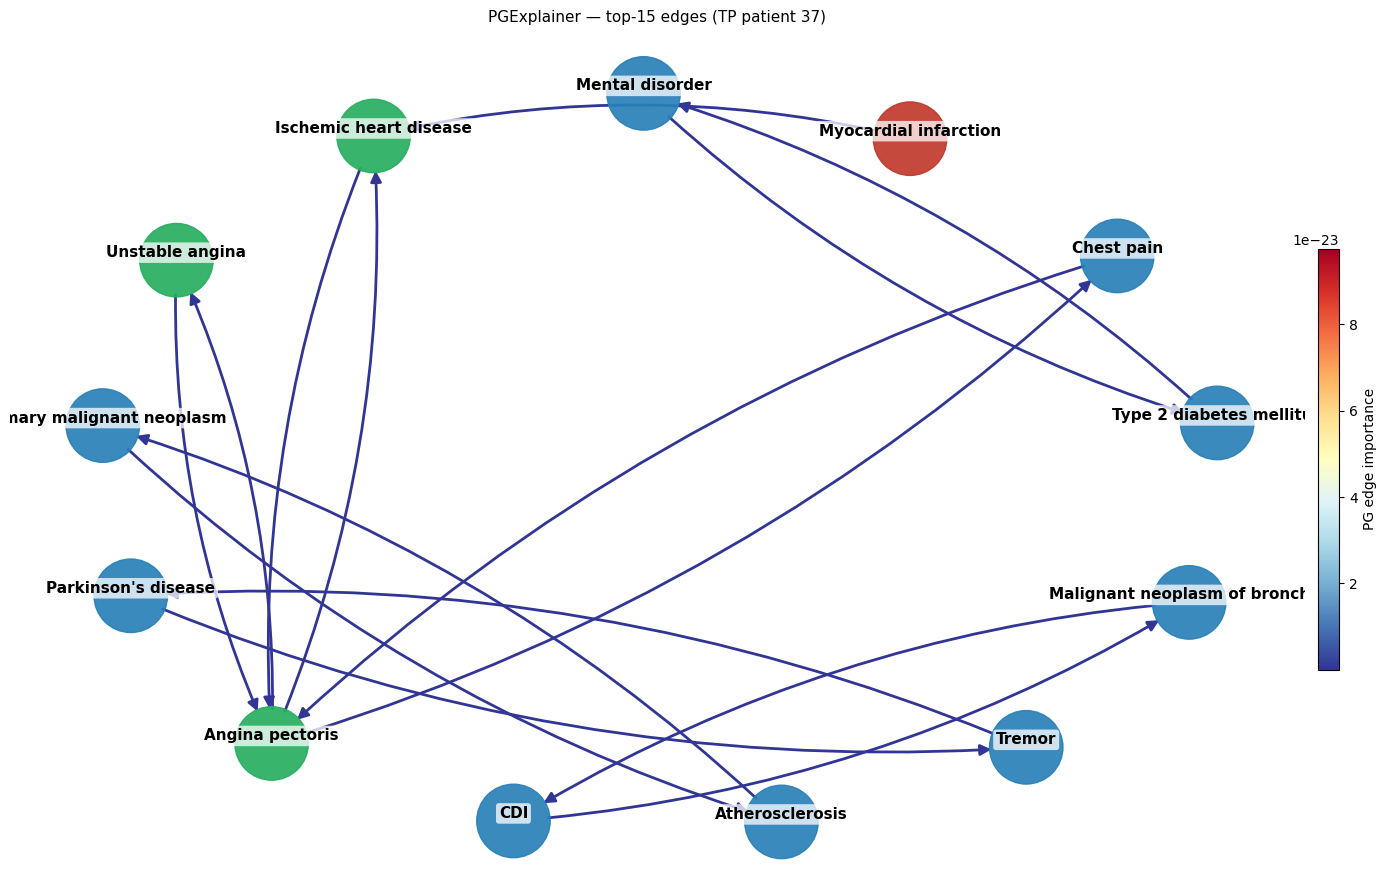

In [79]:
n_pg_epochs = pg_explainer.algorithm.epochs

print(f"Entrenando PGExplainer: {n_pg_epochs} epochs x {len(C_pg)} pacientes...")

# tqdm anidado para mostrar una barra de progreso elegante
for epoch in tqdm(range(n_pg_epochs), desc="Epochs"):
    epoch_loss = 0.0
    for i in range(len(C_pg)):
        pg_wrapper.set_patient(C_pg[i], T_pg[i], L_pg[i], PAD_pg[i], DEMO_pg[i])
        target = torch.tensor([int(Y_pg[i].item())], dtype=torch.long).to(DEVICE)

        loss = pg_explainer.algorithm.train(
            epoch=epoch, model=pg_wrapper, x=x_input,
            edge_index=EDGE_INDEX, target=target
        )

        if loss is not None:
            epoch_loss += float(loss)

    if (epoch + 1) % max(1, n_pg_epochs // 5) == 0:
        avg_loss = epoch_loss / max(len(C_pg), 1)
        print(f"  Epoch {epoch+1:02d}/{n_pg_epochs} - avg loss: {avg_loss:.6f}")

print("PGExplainer training complete.")

# ---- PGExplainer inference demo (ensures visible output) --------------------
if len(true_pos_idx) > 0:
    pi_pg = int(true_pos_idx[0])

    c_pi = C_test[pi_pg].to(DEVICE)
    t_pi = T_test[pi_pg].to(DEVICE)
    l_pi = L_test[pi_pg].to(DEVICE)
    pm_pi = PAD_MASK_test[pi_pg].to(DEVICE)
    dm_pi = DEMO_test[pi_pg].to(DEVICE)

    pg_wrapper.set_patient(c_pi, t_pi, l_pi, pm_pi, dm_pi)

    explanation = pg_explainer(
        x=x_input,
        edge_index=EDGE_INDEX,
        target=torch.tensor([1 if probs_test[pi_pg] >= BEST_THR else 0], device=DEVICE),
    )

    edge_mask = explanation.edge_mask.detach().cpu().numpy()
    ei_np = EDGE_INDEX.detach().cpu().numpy()

    rows_pg = []
    for eidx, score in enumerate(edge_mask):
        if eidx >= ei_np.shape[1]:
            break

        src_i = int(ei_np[0, eidx])
        dst_i = int(ei_np[1, eidx])
        src_c = idx2concept.get(src_i)
        dst_c = idx2concept.get(dst_i)
        if src_c is None or dst_c is None:
            continue

        rows_pg.append({
            "source": id2name.get(src_c, str(src_c)),
            "target": id2name.get(dst_c, str(dst_c)),
            "importance": float(score),
        })

    if rows_pg:
        pg_df = pd.DataFrame(rows_pg).sort_values("importance", ascending=False)
        print(f"\nPGExplainer inference — TP patient {pi_pg} (prob={probs_test[pi_pg]:.3f})")
        print("Top 10 edges by importance:")
        print(pg_df.head(10).to_string(index=False))

        top_k = min(15, len(pg_df))
        sub_pg = nx.DiGraph()
        for _, row in pg_df.head(top_k).iterrows():
            sub_pg.add_edge(row["source"], row["target"], weight=row["importance"])

        if sub_pg.number_of_nodes() > 0:
            draw_ontology_graph(
                sub_pg,
                title=f"PGExplainer — top-{top_k} edges (TP patient {pi_pg})",
                colorbar_label="PG edge importance",
                save_path=PLOTS / "pgexplainer_tp.png",
            )
else:
    print("No TP patients found; skipping PGExplainer inference demo.")

## 2B. GraphMASK

In [80]:
class GraphMASK(nn.Module):
    def __init__(self, hidden_dim, n_edges):
        super().__init__()
        self.gate_mlp = nn.Sequential(
            nn.Linear(2 * hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid(),
        )

    def forward(self, node_emb, edge_index):
        src_emb = node_emb[edge_index[0]]
        dst_emb = node_emb[edge_index[1]]
        return self.gate_mlp(torch.cat([src_emb, dst_emb], dim=-1)).squeeze(-1)


def train_graphmask(patient_idx, n_epochs=50, lambda_sparse=0.5):
    c  = C_test[patient_idx].unsqueeze(0).to(DEVICE)
    t  = T_test[patient_idx].unsqueeze(0).to(DEVICE)
    l  = L_test[patient_idx].unsqueeze(0).to(DEVICE)
    pm = PAD_MASK_test[patient_idx].unsqueeze(0).to(DEVICE)
    dm = DEMO_test[patient_idx].unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        node_emb   = model.ontology_enc(EDGE_INDEX).detach()
        logit_orig = model(EDGE_INDEX, c, t, l, pm, dm)
        prob_orig  = torch.sigmoid(logit_orig).detach()

    gmask = GraphMASK(cfg.HIDDEN_DIM, EDGE_INDEX.shape[1]).to(DEVICE)
    opt   = torch.optim.Adam(gmask.parameters(), lr=0.01)

    for epoch in range(n_epochs):
        gmask.train()
        opt.zero_grad()
        gates = gmask(node_emb.detach(), EDGE_INDEX)

        # Opcional: Warm-up lineal para la esparsidad
        current_lambda = lambda_sparse * (epoch / n_epochs)

        hard_mask = (gates > 0.5).detach()
        ei_masked = EDGE_INDEX[:, hard_mask] if hard_mask.sum() > 0 else EDGE_INDEX
        logit_masked = model(ei_masked, c, t, l, pm, dm)
        prob_masked  = torch.sigmoid(logit_masked)

        fidelity_loss = F.mse_loss(prob_masked, prob_orig)
        sparsity_loss = current_lambda * gates.mean() # Usando el lambda ajustado

        (fidelity_loss + sparsity_loss).backward()
        opt.step()

    return gates.detach().cpu().numpy()


if len(true_pos_idx) > 0:
    pi    = true_pos_idx[0]
    gates = train_graphmask(pi)
    ei_np = EDGE_INDEX.cpu().numpy()
    rows  = []
    for i in range(len(gates)):
        if i >= ei_np.shape[1]: break
        src_c = idx2concept.get(int(ei_np[0, i]))
        dst_c = idx2concept.get(int(ei_np[1, i]))
        if src_c is None or dst_c is None: continue
        rows.append({"source": id2name.get(src_c, str(src_c)),
                     "target": id2name.get(dst_c, str(dst_c)),
                     "gate":   float(gates[i]), "kept": gates[i] > 0.5})
    gm_df = pd.DataFrame(rows).sort_values("gate", ascending=False)
    n_kept, n_total = gm_df["kept"].sum(), len(gm_df)
    print(f"GraphMASK TP patient {pi}: {n_kept}/{n_total} edges kept ({100*n_kept/n_total:.1f}%)")
    print(gm_df.head(10).to_string(index=False))
    sub_gm = nx.DiGraph()
    for _, row in gm_df[gm_df["kept"]].iterrows():
        sub_gm.add_edge(row["source"], row["target"], weight=row["gate"])
    if sub_gm.number_of_edges() > 0:
        draw_ontology_graph(sub_gm,
            title=f"GraphMASK — {n_kept} edges kept",
            colorbar_label="Gate value",
            save_path=PLOTS / "graphmask_faithful_edges.png")

GraphMASK TP patient 37: 0/42 edges kept (0.0%)
                        source                         target         gate  kept
Malignant neoplasm of bronchus                            CDI 1.292752e-14 False
               Unstable angina                Angina pectoris 1.108247e-14 False
               Angina pectoris                Unstable angina 9.352480e-15 False
                           CDI Malignant neoplasm of bronchus 7.736696e-15 False
               Mental disorder       Type 2 diabetes mellitus 7.550215e-15 False
      Type 2 diabetes mellitus                Mental disorder 6.355784e-15 False
                    Chest pain                Angina pectoris 2.723243e-15 False
               Angina pectoris                     Chest pain 2.305647e-15 False
        Ischemic heart disease                Angina pectoris 1.912403e-16 False
               Angina pectoris         Ischemic heart disease 1.318482e-16 False


## 2C. GNN-LRP

FIX v5: the pooling step now uses `model.seq_attn` attention weights
as event relevance, replacing the removed `model.recency_alpha` pooling.

In [81]:
def count_unique_concepts(idx):
    mask = PAD_MASK_test[idx].numpy()
    return len(set(C_test[idx][~mask.astype(bool)].tolist()) - {PAD_IDX})

pi = max(true_pos_idx, key=count_unique_concepts)
n_concepts = count_unique_concepts(pi)
print(f"Selected TP patient {pi}  ({n_concepts} unique active concepts, prob={probs_test[pi]:.3f})")

Selected TP patient 66  (4 unique active concepts, prob=0.674)


GNN-LRP relevance — TP patient 66 (prob=0.674):
  Dementia                                  R = 0.2439
  Mental disorder                           R = 0.2385
  Angina pectoris                           R = 0.0864
  CDI                                       R = 0.0835


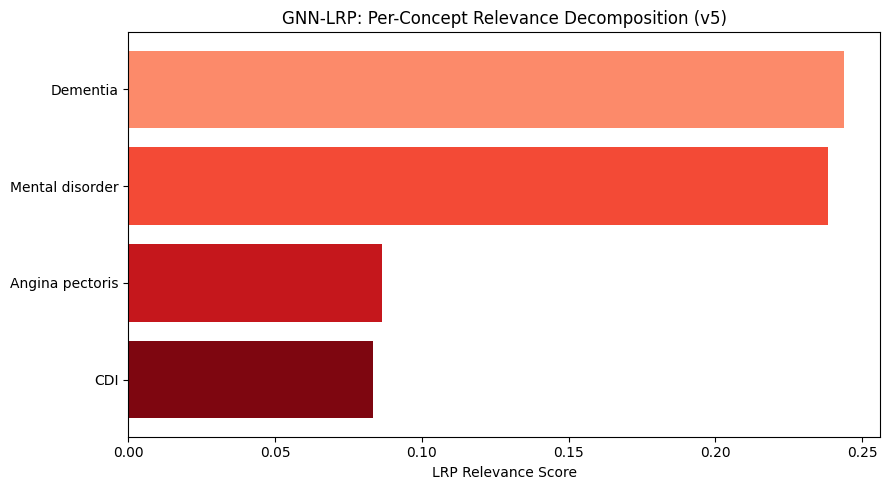

In [82]:
@torch.no_grad()
def gnn_lrp(patient_idx, epsilon=1e-9):
    """
    Layer-wise Relevance Propagation through CardioGNN v5.

    Propagates relevance:
    head output → head layers → patient_rep → SequenceAttention weights
    → per-event relevance → per-concept relevance.

    FIX: uses model.seq_attn attention weights instead of removed
    recency_alpha weighted-mean pooling.
    """
    c  = C_test[patient_idx].to(DEVICE)
    t  = T_test[patient_idx].unsqueeze(0).to(DEVICE)
    pm = PAD_MASK_test[patient_idx].unsqueeze(0).to(DEVICE)
    dm = DEMO_test[patient_idx].unsqueeze(0).to(DEVICE)

    # ── Forward pass ──────────────────────────────────────────────────
    node_emb = model.ontology_enc(EDGE_INDEX)
    safe_c   = c.clamp(max=node_emb.shape[0] - 1)
    x        = node_emb[safe_c].unsqueeze(0) + model.time_enc(t)  # [1, T, H]

    patient_rep, attn_weights = model.seq_attn(x, pm)  # [1, H], [1, T]
    patient_rep_d = model.drop(patient_rep)             # dropout off in eval

    # Head: Linear(H, H//2) → GELU → Dropout → Linear(H//2, 1)
    h1    = F.gelu(model.head[0](patient_rep_d))        # [1, H//2]
    logit = model.head[3](h1).squeeze()                 # scalar

    # ── LRP backward ──────────────────────────────────────────────────
    R_out = logit.item()  # relevance at output = logit value

    # Step 1: Through Linear(H//2, 1)
    W2   = model.head[3].weight.data          # [1, H//2]
    b2   = model.head[3].bias.data            # [1]
    z2   = (h1 @ W2.T + b2).squeeze()        # scalar
    R_h1 = (h1.squeeze() * W2.squeeze() /
            (z2.item() + epsilon * (1 if z2.item() >= 0 else -1))) * R_out  # [H//2]

    # Step 2: Through GELU (treat as identity for LRP — conservative)
    # Step 3: Through Linear(H, H//2)
    W1   = model.head[0].weight.data          # [H//2, H]
    b1   = model.head[0].bias.data            # [H//2]
    z1   = (patient_rep_d @ W1.T + b1)       # [1, H//2]
    R_patient_rep = patient_rep_d.squeeze(0) * (W1.T @ (R_h1 / (z1.squeeze() + epsilon)))                                   # [H]

    # Step 4: Distribute patient_rep relevance through SequenceAttention
    # SequenceAttention produces patient_rep = weighted sum of events.
    # Relevance at patient_rep distributes to events proportional to attn_weights.
    R_scalar  = R_patient_rep.abs().sum().item()
    ew        = attn_weights.squeeze(0)         # [T] — sums to 1
    R_event   = (ew * R_scalar).cpu().numpy()  # [T]

    # Step 5: Map event relevance to concept indices
    mask_np = pm.squeeze(0).cpu().numpy()
    concept_relevance = {}
    for i in range(len(mask_np)):
        if mask_np[i]: continue
        cidx = c[i].item()
        if cidx >= NUM_CONCEPTS: continue
        concept_relevance[cidx] = concept_relevance.get(cidx, 0) + float(R_event[i])

    return concept_relevance


if len(true_pos_idx) > 0:
    lrp_rel = gnn_lrp(pi)
    lrp_sorted = sorted(lrp_rel.items(), key=lambda x: x[1], reverse=True)
    print(f"GNN-LRP relevance — TP patient {pi} (prob={probs_test[pi]:.3f}):")
    for cidx, rel in lrp_sorted[:10]:
        cid = idx2concept[cidx]
        print(f"  {id2name.get(cid, str(cid)):40s}  R = {rel:.4f}")

    fig, ax = plt.subplots(figsize=(9, 5))
    names  = [id2name.get(idx2concept[c], str(c)) for c, _ in lrp_sorted[:10]]
    vals   = [r for _, r in lrp_sorted[:10]]
    colors = plt.cm.Reds(np.linspace(0.4, 0.95, len(vals)))
    ax.barh(names[::-1], vals[::-1], color=colors[::-1])
    ax.set_xlabel("LRP Relevance Score")
    ax.set_title("GNN-LRP: Per-Concept Relevance Decomposition (v5)")
    plt.tight_layout()
    plt.savefig(PLOTS / "gnn_lrp_tp.png", dpi=220, bbox_inches="tight")
    plt.show()

## 2D. SubgraphX — Monte Carlo Tree Search + Shapley

SubgraphX — TP patient 66 (prob=0.674):
  Best subgraph (budget=5): score=0.745
    Mental disorder
    CDI
    Angina pectoris
    Dementia


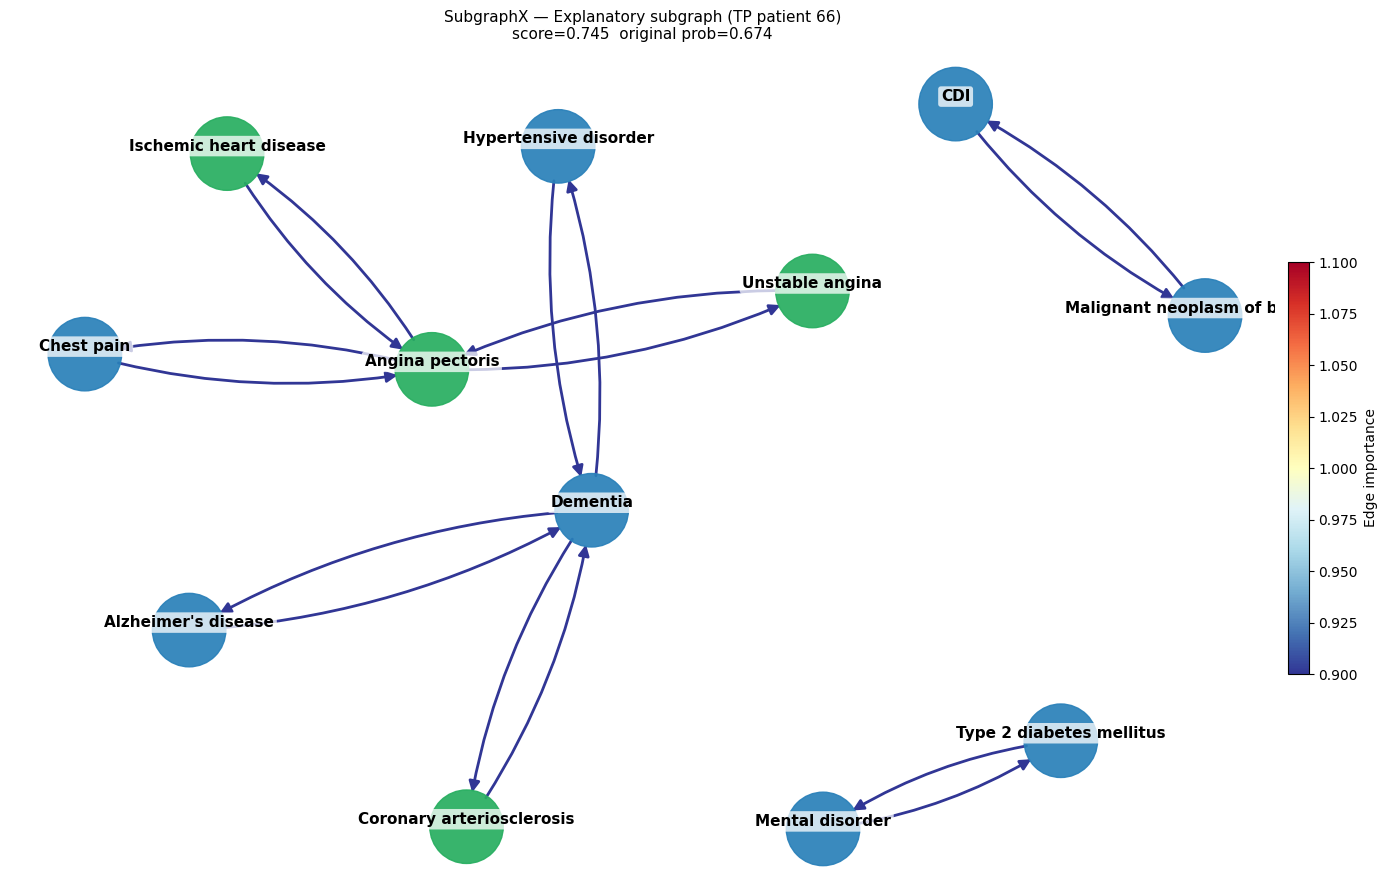

In [83]:
class SubgraphXExplainer:
    """
    Simplified SubgraphX: find the connected subgraph of size `budget`
    that maximises the marginal Shapley contribution to the prediction.
    Uses greedy expansion with random restarts (Monte Carlo).
    """
    def __init__(self, model, edge_index, num_concepts, n_samples=100):
        self.model        = model
        self.edge_index   = edge_index
        self.num_concepts = num_concepts
        self.n_samples    = n_samples

    @torch.no_grad()
    def _predict_with_subgraph(self, patient_idx, node_subset):
        c  = C_test[patient_idx].unsqueeze(0).to(DEVICE)
        t  = T_test[patient_idx].unsqueeze(0).to(DEVICE)
        l  = L_test[patient_idx].unsqueeze(0).to(DEVICE)
        pm = PAD_MASK_test[patient_idx].unsqueeze(0).to(DEVICE)
        dm = DEMO_test[patient_idx].unsqueeze(0).to(DEVICE)
        ei_np = self.edge_index.cpu().numpy()
        mask  = (np.isin(ei_np[0], list(node_subset)) &
                 np.isin(ei_np[1], list(node_subset)))
        if mask.sum() == 0:
            ei_sub = torch.zeros(2, 0, dtype=torch.long, device=DEVICE)
        else:
            ei_sub = self.edge_index[:, torch.tensor(mask, device=DEVICE)]
        return torch.sigmoid(self.model(ei_sub, c, t, l, pm, dm)).item()

    def _marginal_contribution(self, patient_idx, node_subset, target_node):
        return (self._predict_with_subgraph(patient_idx, node_subset | {target_node}) -
                self._predict_with_subgraph(patient_idx, node_subset - {target_node}))

    def explain(self, patient_idx, budget=5, n_restarts=20):
        mask_np = PAD_MASK_test[patient_idx].numpy()
        active = set()
        for i in range(len(mask_np)):
            if mask_np[i]: continue
            cidx = C_test[patient_idx][i].item()
            if cidx < self.num_concepts:
                active.add(cidx)

        if len(active) <= budget:
            return active, self._predict_with_subgraph(patient_idx, active)

        ei_np = self.edge_index.cpu().numpy()
        adj   = defaultdict(set)
        for i in range(ei_np.shape[1]):
            s, d = int(ei_np[0, i]), int(ei_np[1, i])
            if s in active or d in active:
                adj[s].add(d); adj[d].add(s)

        best_subset, best_score = None, -float('inf')
        rng, active_list = np.random.RandomState(42), list(active)

        for _ in range(n_restarts):
            seed   = rng.choice(active_list)
            subset = {seed}
            for _ in range(budget - 1):
                candidates = set()
                for n in subset:
                    candidates.update(adj.get(n, set()) & active)
                candidates -= subset
                if not candidates:
                    remaining = active - subset
                    if not remaining: break
                    candidates = remaining
                best_cand, best_mc = None, -float('inf')
                for cand in candidates:
                    mc = self._marginal_contribution(patient_idx, subset, cand)
                    if mc > best_mc:
                        best_mc, best_cand = mc, cand
                if best_cand is not None:
                    subset.add(best_cand)
            score = self._predict_with_subgraph(patient_idx, subset)
            if score > best_score:
                best_score, best_subset = score, subset.copy()

        return best_subset, best_score


subgraphx = SubgraphXExplainer(model, EDGE_INDEX, NUM_CONCEPTS, n_samples=50)

if len(true_pos_idx) > 0:
    print(f"SubgraphX — TP patient {pi} (prob={probs_test[pi]:.3f}):")
    best_nodes, best_score = subgraphx.explain(pi, budget=5)
    print(f"  Best subgraph (budget=5): score={best_score:.3f}")
    for nidx in best_nodes:
        cid = idx2concept[nidx]
        print(f"    {id2name.get(cid, str(cid))}")

    ei_np  = EDGE_INDEX.cpu().numpy()
    sub_sx = nx.DiGraph()
    node_subset = set(best_nodes)
    for i in range(ei_np.shape[1]):
        s, d = int(ei_np[0, i]), int(ei_np[1, i])
        if s in node_subset or d in node_subset:
            sc = idx2concept.get(s)
            dc = idx2concept.get(d)
            if sc is None or dc is None:
                continue
            src_name = id2name.get(sc, str(sc))
            dst_name = id2name.get(dc, str(dc))
            sub_sx.add_edge(src_name, dst_name, weight=1.0)
    for nidx in best_nodes:
        cid = idx2concept.get(nidx)
        if cid is None:
            continue
        name = id2name.get(cid, str(cid))
        sub_sx.add_node(name)
    if sub_sx.number_of_edges() == 0:
        print("  Note: no ontology edges connect the selected concepts; showing node-only view.")

    if sub_sx.number_of_nodes() > 0:
        draw_ontology_graph(sub_sx,
            title=f"SubgraphX — Explanatory subgraph (TP patient {pi})\n"
                  f"score={best_score:.3f}  original prob={probs_test[pi]:.3f}",
            save_path=PLOTS / "subgraphx_tp.png")

## 2E. Concept SHAP — Per-Concept Shapley Values

FIX: replaced `np.math.factorial` (removed in NumPy 2.x) with `math.factorial`.

Concept SHAP — TP patient 66 (prob=0.674):
  CDI                                       φ = +0.0941
  Angina pectoris                           φ = +0.0914
  Mental disorder                           φ = +0.0204
  Dementia                                  φ = +0.0192

  Sum of Shapley values: 0.2252
  v(N) check           : 0.6239


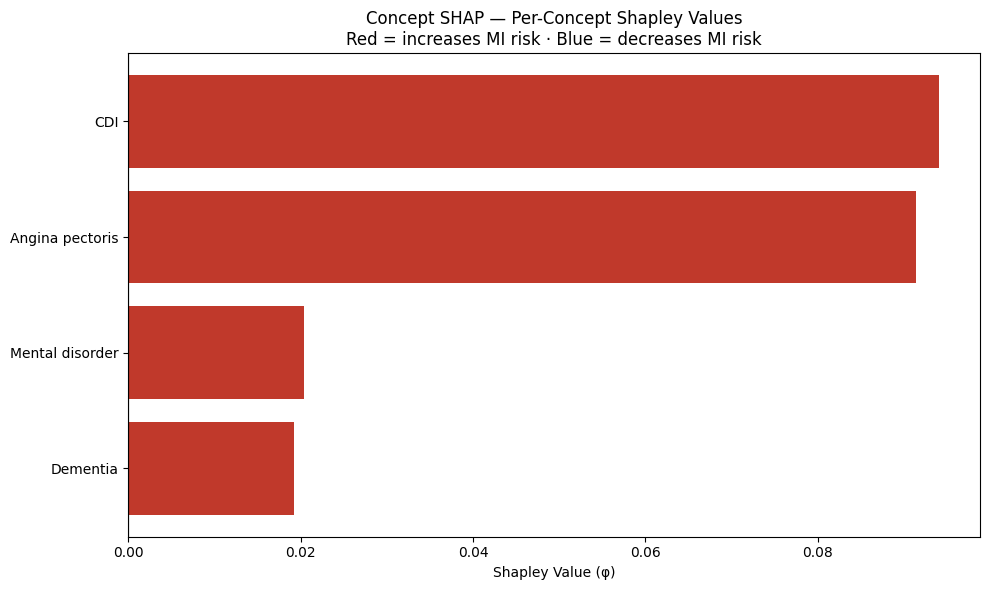

In [84]:
@torch.no_grad()
def concept_shap(patient_idx: int, max_exact: int = 12, n_samples: int = 200) -> Dict[int, float]:
    """
    Calcula los valores Shapley para cada concepto activo de un paciente.
    Uso de cálculo exacto si n <= max_exact, de lo contrario muestreo de Monte Carlo.
    """
    mask_np = PAD_MASK_test[patient_idx].numpy()
    active_concepts = []
    
    for i in range(len(mask_np)):
        if mask_np[i]: 
            continue
        cidx = C_test[patient_idx][i].item()
        if cidx < NUM_CONCEPTS and cidx not in active_concepts:
            active_concepts.append(cidx)
            
    if not active_concepts:
        return {}

    def predict_subset(concept_subset: Set[int]) -> float:
        """Función auxiliar para predecir la probabilidad usando solo un subconjunto de conceptos."""
        concepts_masked = C_test[patient_idx].clone()
        
        # Enmascarar conceptos que no están en el subconjunto
        for pos in range(len(concepts_masked)):
            cidx = concepts_masked[pos].item()
            if cidx != PAD_IDX and cidx not in concept_subset:
                concepts_masked[pos] = PAD_IDX
                
        # Preparar tensores para el modelo
        c_tensor = concepts_masked.unsqueeze(0).to(DEVICE)
        t_tensor = T_test[patient_idx].unsqueeze(0).to(DEVICE)
        l_tensor = L_test[patient_idx].unsqueeze(0).to(DEVICE)
        pad_mask_tensor = (concepts_masked == PAD_IDX).unsqueeze(0).to(DEVICE)
        demo_tensor = DEMO_test[patient_idx].unsqueeze(0).to(DEVICE)
        
        logit = model(EDGE_INDEX, c_tensor, t_tensor, l_tensor, pad_mask_tensor, demo_tensor)
        return torch.sigmoid(logit).item()

    n = len(active_concepts)
    shap_values = {c: 0.0 for c in active_concepts}

    if n <= max_exact:
        # Cálculo exacto iterando por todas las combinaciones posibles
        for concept in active_concepts:
            others = [c for c in active_concepts if c != concept]
            sv = 0.0
            
            for size in range(len(others) + 1):
                for subset in itertools.combinations(others, size):
                    subset_set = set(subset)
                    v_with = predict_subset(subset_set | {concept})
                    v_without = predict_subset(subset_set)
                    
                    weight = (math.factorial(size) * math.factorial(n - size - 1) / math.factorial(n))
                    sv += weight * (v_with - v_without)
                    
            shap_values[concept] = sv
    else:
        # Aproximación de Monte Carlo con TQDM para ver el progreso
        rng = np.random.RandomState(42)
        for _ in tqdm(range(n_samples), desc="Monte Carlo SHAP"):
            perm = rng.permutation(active_concepts)
            coalition = set()
            prev_val = predict_subset(coalition)
            
            for concept in perm:
                coalition.add(concept)
                new_val = predict_subset(coalition)
                shap_values[concept] += (new_val - prev_val) / n_samples
                prev_val = new_val

    return shap_values


if len(true_pos_idx) > 0:
    shap = concept_shap(pi)
    shap_sorted = sorted(shap.items(), key=lambda x: x[1], reverse=True)
    print(f"Concept SHAP — TP patient {pi} (prob={probs_test[pi]:.3f}):")
    for cidx, sv in shap_sorted:
        cid = idx2concept[cidx]
        print(f"  {id2name.get(cid, str(cid)):40s}  φ = {sv:+.4f}")

    total_shap = sum(shap.values())
    print(f"\n  Sum of Shapley values: {total_shap:.4f}")
    print(f"  v(N) check           : {predict_prob_single(pi):.4f}")

    fig, ax = plt.subplots(figsize=(10, 6))
    names  = [id2name.get(idx2concept[c], str(c)) for c, _ in shap_sorted]
    vals   = [sv for _, sv in shap_sorted]
    colors = ["#c0392b" if v > 0 else "#2980b9" for v in vals]
    ax.barh(names[::-1], vals[::-1], color=colors[::-1])
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("Shapley Value (φ)")
    ax.set_title("Concept SHAP — Per-Concept Shapley Values\n"
                 "Red = increases MI risk · Blue = decreases MI risk")
    plt.tight_layout()
    plt.savefig(PLOTS / "concept_shap_tp.png", dpi=220, bbox_inches="tight")
    plt.show()

CF-GNNExplainer-style — TP patient 66
  Original probability     : 0.626
  Counterfactual probability: 0.417
  Removed edges             : 1


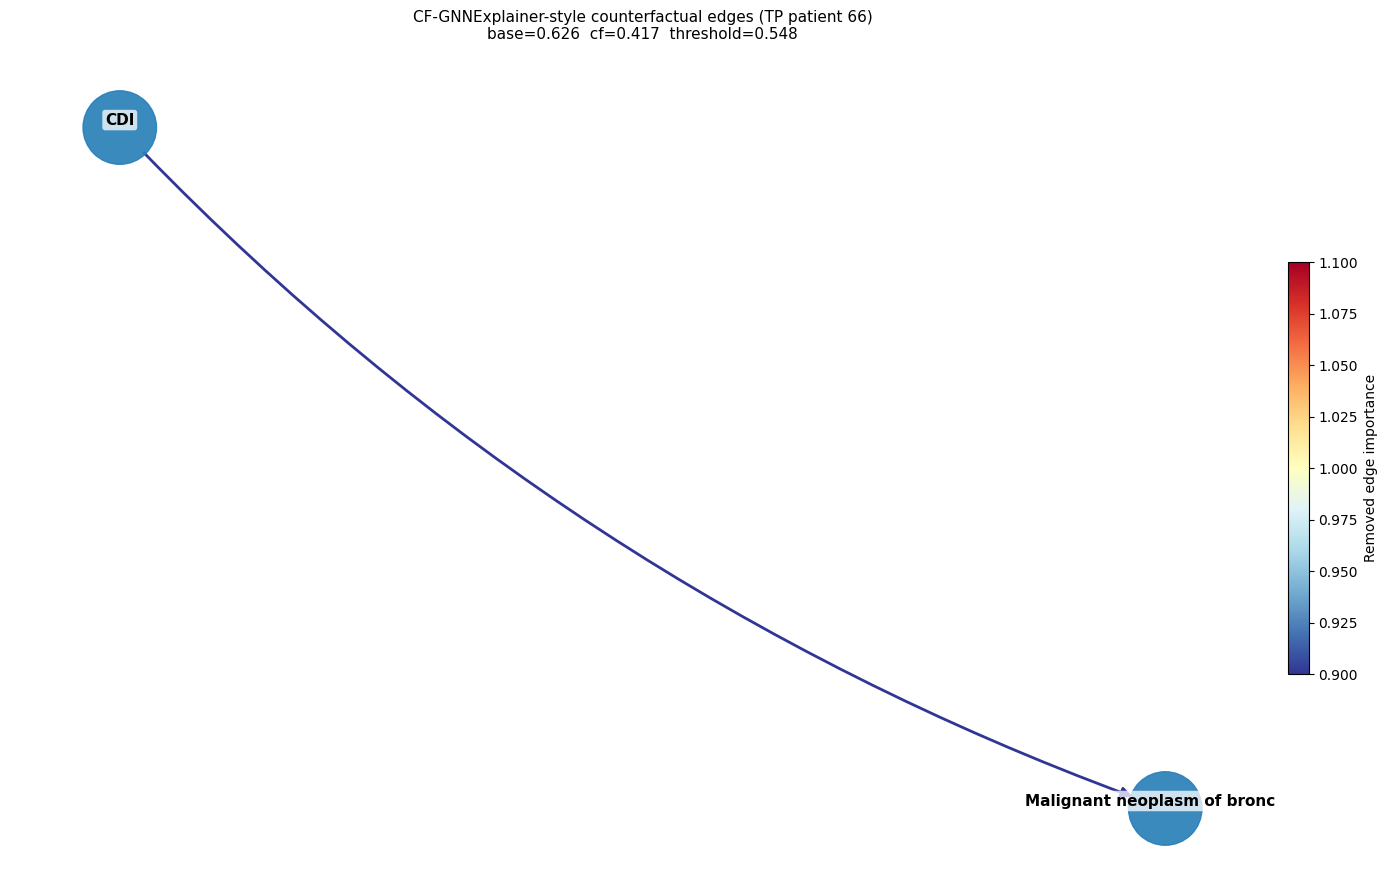

In [85]:
# CF-GNNExplainer-style counterfactual search
class CounterfactualExplainer:
    def __init__(self, model, edge_index):
        self.model = model
        self.edge_index = edge_index.to(DEVICE)

    @torch.no_grad()
    def _predict_prob(self, patient_idx, edge_index):
        c  = C_test[patient_idx].unsqueeze(0).to(DEVICE)
        t  = T_test[patient_idx].unsqueeze(0).to(DEVICE)
        l  = L_test[patient_idx].unsqueeze(0).to(DEVICE)
        pm = PAD_MASK_test[patient_idx].unsqueeze(0).to(DEVICE)
        dm = DEMO_test[patient_idx].unsqueeze(0).to(DEVICE)
        edge_index = edge_index.to(DEVICE)

        if edge_index.numel() == 0:
            edge_index = torch.zeros((2, 0), dtype=torch.long, device=DEVICE)

        return torch.sigmoid(self.model(edge_index, c, t, l, pm, dm)).item()

    def explain(self, patient_idx, max_remove=8):
        base_prob = self._predict_prob(patient_idx, self.edge_index)
        target_label = 0 if base_prob >= BEST_THR else 1
        current_mask = torch.ones(self.edge_index.shape[1], dtype=torch.bool, device=DEVICE)
        removed_edges = []
        current_prob = base_prob

        for _ in range(max_remove):
            if (target_label == 0 and current_prob < BEST_THR) or (target_label == 1 and current_prob >= BEST_THR):
                break

            candidate_idx = None
            candidate_prob = current_prob
            remaining_indices = torch.nonzero(current_mask, as_tuple=False).flatten().tolist()

            for edge_idx in remaining_indices:
                trial_mask = current_mask.clone()
                trial_mask[edge_idx] = False
                trial_edge_index = self.edge_index[:, trial_mask]
                trial_prob = self._predict_prob(patient_idx, trial_edge_index)

                if target_label == 0:
                    better = trial_prob < candidate_prob - 1e-9
                else:
                    better = trial_prob > candidate_prob + 1e-9

                if better:
                    candidate_idx = edge_idx
                    candidate_prob = trial_prob

            if candidate_idx is None:
                break

            current_mask[candidate_idx] = False
            removed_edges.append(candidate_idx)
            current_prob = candidate_prob

        return base_prob, current_prob, removed_edges, current_mask


if len(true_pos_idx) > 0:
    cf_explainer = CounterfactualExplainer(model, EDGE_INDEX)
    base_prob, cf_prob, removed_edges, kept_mask = cf_explainer.explain(pi, max_remove=8)

    print(f"CF-GNNExplainer-style — TP patient {pi}")
    print(f"  Original probability     : {base_prob:.3f}")
    print(f"  Counterfactual probability: {cf_prob:.3f}")
    print(f"  Removed edges             : {len(removed_edges)}")

    removed_graph = nx.DiGraph()
    ei_np = EDGE_INDEX.cpu().numpy()
    for edge_idx in removed_edges:
        src_idx = int(ei_np[0, edge_idx])
        dst_idx = int(ei_np[1, edge_idx])
        src_concept = idx2concept.get(src_idx)
        dst_concept = idx2concept.get(dst_idx)
        if src_concept is None or dst_concept is None:
            continue
        src_name = id2name.get(src_concept, str(src_concept))
        dst_name = id2name.get(dst_concept, str(dst_concept))
        removed_graph.add_edge(src_name, dst_name, weight=1.0)

    if removed_graph.number_of_nodes() > 0:
        draw_ontology_graph(
            removed_graph,
            title=f"CF-GNNExplainer-style counterfactual edges (TP patient {pi})\n"
                  f"base={base_prob:.3f}  cf={cf_prob:.3f}  threshold={BEST_THR:.3f}",
            colorbar_label="Removed edge importance",
            save_path=PLOTS / "cf_gnnexplainer_tp.png",
        )

GNNShap-style edge attribution — TP patient 66
  Cerebrovascular disease                  -> Parkinson's disease                       +0.0221
  Chest pain                               -> Angina pectoris                           -0.0178
  Primary malignant neoplasm               -> Atherosclerosis                           -0.0171
  Mental disorder                          -> Type 2 diabetes mellitus                  +0.0159
  Akinesia                                 -> Parkinson's disease                       +0.0138
  Angina pectoris                          -> Ischemic heart disease                    -0.0136
  Arthritis                                -> Senile dementia                           -0.0126
  Malignant neoplasm of bronchus           -> CDI                                       +0.0120
  Parkinson's disease                      -> Akinesia                                  -0.0110
  Congestive heart failure                 -> Heart failure                             +

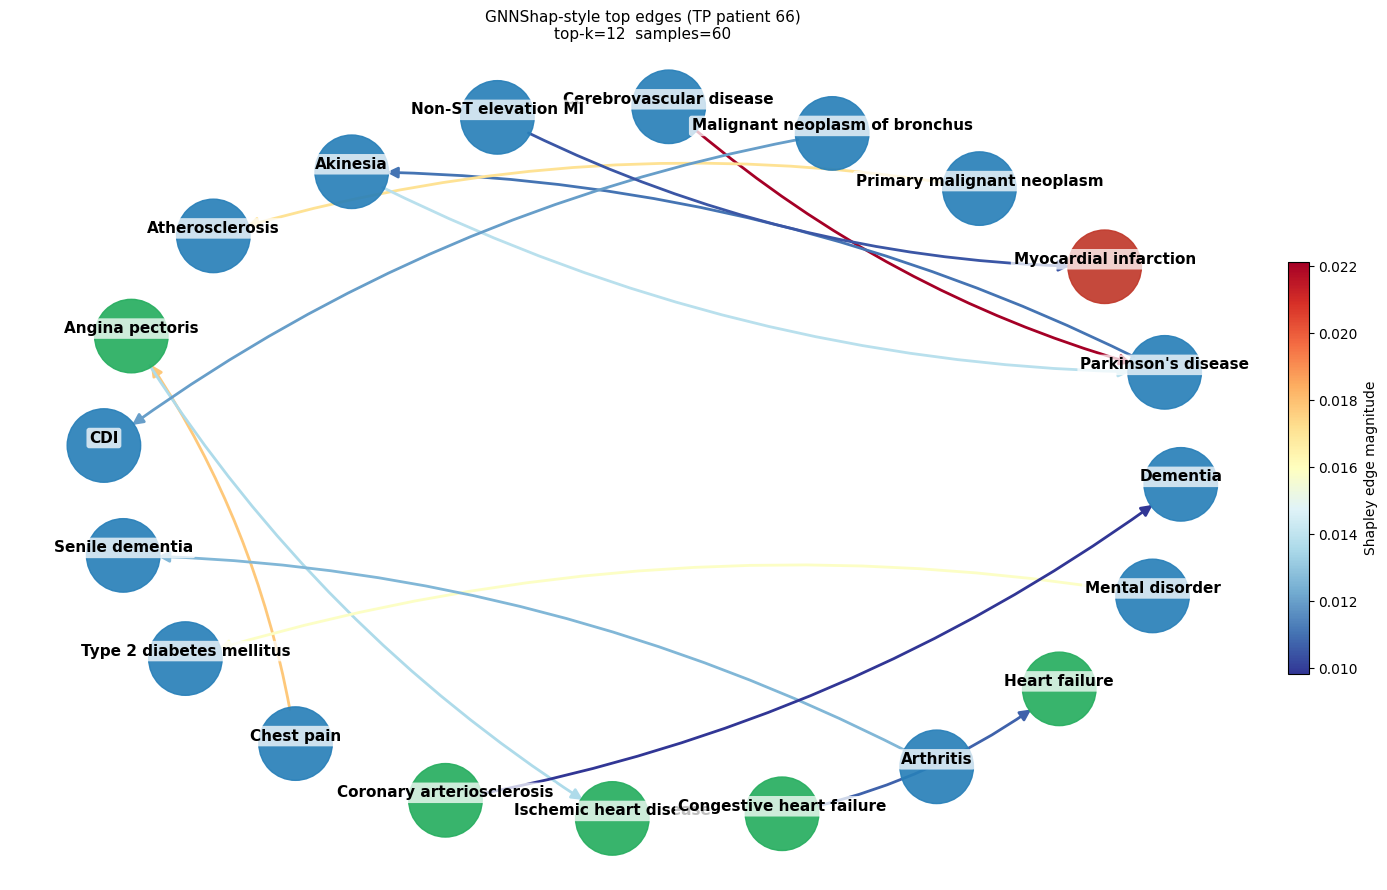

RCExplainer-style rule subgraph — TP patient 66
  Base probability: 0.658
  Node/edge rules selected: 8
  CDI                                      -> Malignant neoplasm of bronchus
  Malignant neoplasm of bronchus           -> CDI
  Angina pectoris                          -> Chest pain
  Chest pain                               -> Angina pectoris
  Angina pectoris                          -> Unstable angina
  Unstable angina                          -> Angina pectoris
  Angina pectoris                          -> Ischemic heart disease
  Ischemic heart disease                   -> Angina pectoris


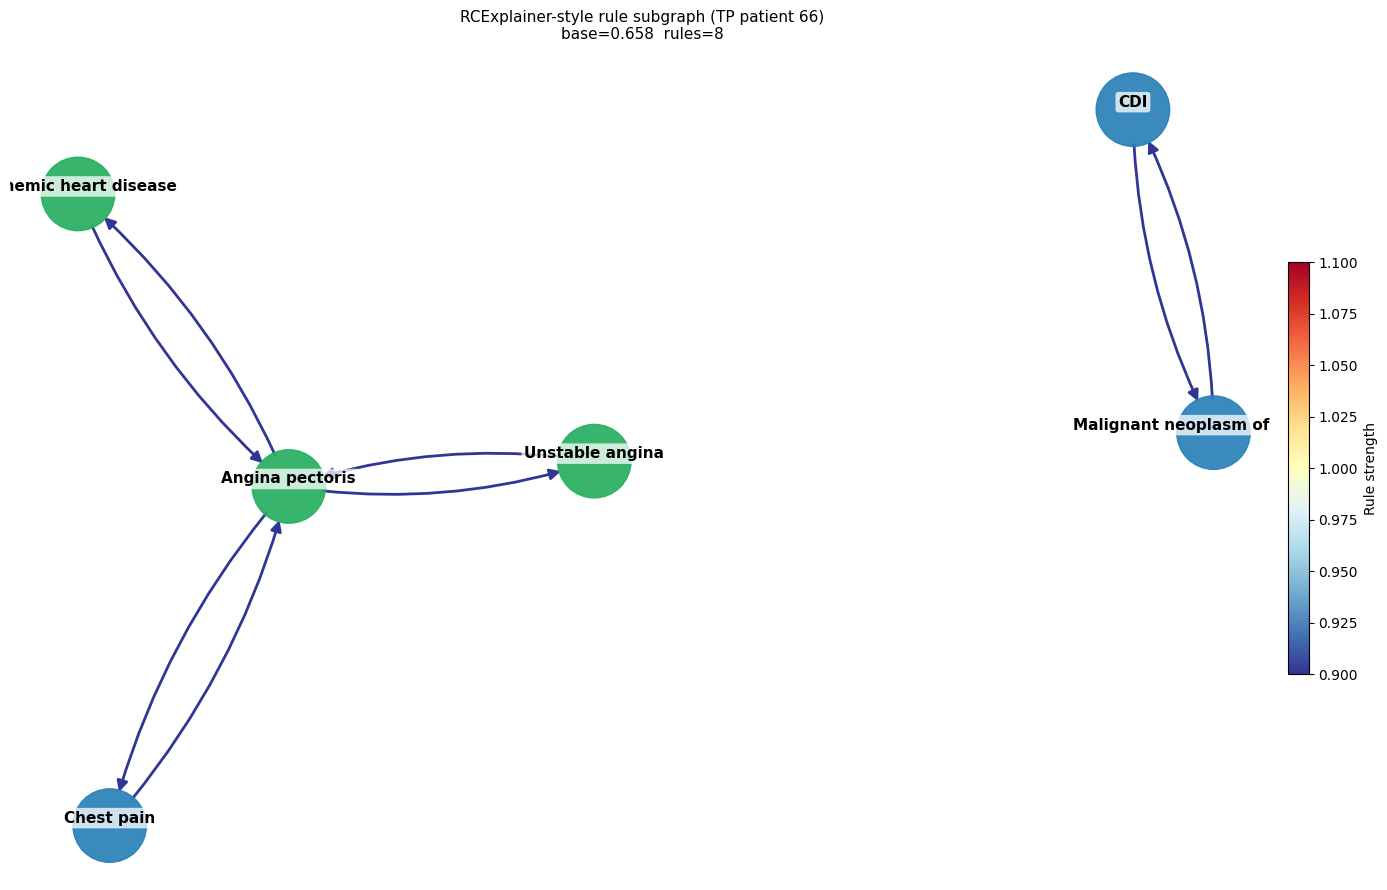

In [86]:
# GNNShap-style edge attribution via Monte Carlo Shapley sampling
class GNNShapExplainer:
    def __init__(self, model, edge_index):
        self.model = model
        self.edge_index = edge_index.to(DEVICE)

    @torch.no_grad()
    def _predict_prob(self, patient_idx, edge_index):
        c  = C_test[patient_idx].unsqueeze(0).to(DEVICE)
        t  = T_test[patient_idx].unsqueeze(0).to(DEVICE)
        l  = L_test[patient_idx].unsqueeze(0).to(DEVICE)
        pm = PAD_MASK_test[patient_idx].unsqueeze(0).to(DEVICE)
        dm = DEMO_test[patient_idx].unsqueeze(0).to(DEVICE)
        if edge_index.numel() == 0:
            edge_index = torch.zeros((2, 0), dtype=torch.long, device=DEVICE)
        return torch.sigmoid(self.model(edge_index, c, t, l, pm, dm)).item()

    def explain(self, patient_idx, n_samples=80, max_edges=12):
        edge_total = self.edge_index.shape[1]
        if edge_total == 0:
            return [], {}

        rng = np.random.RandomState(42)
        scores = np.zeros(edge_total, dtype=np.float64)

        for _ in range(n_samples):
            perm = rng.permutation(edge_total)
            chosen = set()
            prev_prob = self._predict_prob(patient_idx, self.edge_index[:, []])
            for edge_idx in perm:
                chosen.add(int(edge_idx))
                trial_mask = torch.zeros(edge_total, dtype=torch.bool, device=DEVICE)
                trial_mask[list(chosen)] = True
                trial_prob = self._predict_prob(patient_idx, self.edge_index[:, trial_mask])
                scores[edge_idx] += trial_prob - prev_prob
                prev_prob = trial_prob

        scores /= float(n_samples)
        ranked = np.argsort(-np.abs(scores))[:max_edges]
        top_edges = []
        for edge_idx in ranked:
            src_idx = int(self.edge_index[0, edge_idx].item())
            dst_idx = int(self.edge_index[1, edge_idx].item())
            src_concept = idx2concept.get(src_idx)
            dst_concept = idx2concept.get(dst_idx)
            if src_concept is None or dst_concept is None:
                continue
            top_edges.append({
                "edge_idx": int(edge_idx),
                "source": id2name.get(src_concept, str(src_concept)),
                "target": id2name.get(dst_concept, str(dst_concept)),
                "score": float(scores[edge_idx]),
                "abs_score": float(abs(scores[edge_idx])),
            })
        return top_edges, {i: float(scores[i]) for i in ranked}


if len(true_pos_idx) > 0:
    gnnshap = GNNShapExplainer(model, EDGE_INDEX)
    top_edges, edge_scores = gnnshap.explain(pi, n_samples=60, max_edges=12)
    print(f"GNNShap-style edge attribution — TP patient {pi}")
    for edge_info in top_edges[:10]:
        direction = "+" if edge_info['score'] >= 0 else "-"
        print(f"  {edge_info['source']:40s} -> {edge_info['target']:40s}  {direction}{abs(edge_info['score']):.4f}")

    gnnshap_graph = nx.DiGraph()
    for edge_info in top_edges:
        gnnshap_graph.add_edge(edge_info['source'], edge_info['target'], weight=edge_info['abs_score'])

    if gnnshap_graph.number_of_nodes() > 0:
        draw_ontology_graph(
            gnnshap_graph,
            title=f"GNNShap-style top edges (TP patient {pi})\n"
                  f"top-k=12  samples=60",
            colorbar_label="Shapley edge magnitude",
            save_path=PLOTS / "gnnshap_tp.png",
        )

# RCExplainer-style rule-based counterfactual subgraph
class RCExplainerStyle:
    def __init__(self, model, edge_index):
        self.model = model
        self.edge_index = edge_index.to(DEVICE)

    @torch.no_grad()
    def _predict_prob(self, patient_idx, edge_index):
        c  = C_test[patient_idx].unsqueeze(0).to(DEVICE)
        t  = T_test[patient_idx].unsqueeze(0).to(DEVICE)
        l  = L_test[patient_idx].unsqueeze(0).to(DEVICE)
        pm = PAD_MASK_test[patient_idx].unsqueeze(0).to(DEVICE)
        dm = DEMO_test[patient_idx].unsqueeze(0).to(DEVICE)
        if edge_index.numel() == 0:
            edge_index = torch.zeros((2, 0), dtype=torch.long, device=DEVICE)
        return torch.sigmoid(self.model(edge_index, c, t, l, pm, dm)).item()

    def explain(self, patient_idx, hop_limit=2, max_rules=6):
        base_prob = self._predict_prob(patient_idx, self.edge_index)
        active_mask = ~PAD_MASK_test[patient_idx].cpu().numpy().astype(bool)
        active_concepts = [int(C_test[patient_idx][i].item()) for i in range(len(active_mask)) if active_mask[i] and int(C_test[patient_idx][i].item()) != PAD_IDX]
        active_set = set(active_concepts)

        if not active_set:
            return base_prob, [], nx.DiGraph()

        ei_np = self.edge_index.cpu().numpy()
        concept_neighbors = defaultdict(set)
        for src_idx, dst_idx in zip(ei_np[0], ei_np[1]):
            src_concept = idx2concept.get(int(src_idx))
            dst_concept = idx2concept.get(int(dst_idx))
            if src_concept is None or dst_concept is None:
                continue
            concept_neighbors[int(src_idx)].add(int(dst_idx))
            concept_neighbors[int(dst_idx)].add(int(src_idx))

        seed_nodes = active_set.copy()
        frontier = set(seed_nodes)
        for _ in range(hop_limit):
            next_frontier = set()
            for node_idx in frontier:
                next_frontier.update(concept_neighbors.get(node_idx, set()))
            next_frontier -= seed_nodes
            seed_nodes.update(next_frontier)
            frontier = next_frontier
            if not frontier:
                break

        selected_edges = []
        rule_graph = nx.DiGraph()
        for src_idx, dst_idx in zip(ei_np[0], ei_np[1]):
            if int(src_idx) not in seed_nodes and int(dst_idx) not in seed_nodes:
                continue
            src_concept = idx2concept.get(int(src_idx))
            dst_concept = idx2concept.get(int(dst_idx))
            if src_concept is None or dst_concept is None:
                continue
            src_name = id2name.get(src_concept, str(src_concept))
            dst_name = id2name.get(dst_concept, str(dst_concept))
            rule_graph.add_edge(src_name, dst_name, weight=1.0)
            selected_edges.append((src_name, dst_name))
            if len(selected_edges) >= max_rules:
                break

        if rule_graph.number_of_nodes() == 0:
            for concept_idx in list(seed_nodes)[:max_rules]:
                cid = idx2concept.get(concept_idx)
                if cid is not None:
                    rule_graph.add_node(id2name.get(cid, str(cid)))

        rule_prob = self._predict_prob(patient_idx, self.edge_index[:, []])
        return base_prob, selected_edges, rule_graph, rule_prob


if len(true_pos_idx) > 0:
    rc_explainer = RCExplainerStyle(model, EDGE_INDEX)
    base_prob, selected_edges, rule_graph, empty_prob = rc_explainer.explain(pi, hop_limit=2, max_rules=8)
    print(f"RCExplainer-style rule subgraph — TP patient {pi}")
    print(f"  Base probability: {base_prob:.3f}")
    print(f"  Node/edge rules selected: {len(selected_edges)}")
    for src_name, dst_name in selected_edges[:8]:
        print(f"  {src_name:40s} -> {dst_name}")

    if rule_graph.number_of_nodes() > 0:
        draw_ontology_graph(
            rule_graph,
            title=f"RCExplainer-style rule subgraph (TP patient {pi})\n"
                  f"base={base_prob:.3f}  rules={len(selected_edges)}",
            colorbar_label="Rule strength",
            save_path=PLOTS / "rcexplainer_tp.png",
        )

## 3. Method Comparison Summary — Complete GNN Explainability Toolkit

| Method       | Type                  | Scope        | Speed                 | Faithfulness | Key output                    |
|:-----------|:-----------|:-----------|:-----------|:-----------|:-----------|
| GNNExplainer | Perturbation          | Local        | Slow                  | Moderate     | Minimal subgraph              |
| PGExplainer  | Learned               | Global+Local | Fast                  | Good         | Edge importance               |
| GraphMASK    | Differentiable gates  | Global       | Fast (after training) | High         | Faithful edge subset          |
| GNN-LRP      | Relevance propagation | Local        | Fast                  | High         | Per-node relevance            |
| SubgraphX    | MCTS + Shapley        | Local        | Slow                  | High         | Connected subgraph            |
| CF2          | Greedy counterfactual search | Local | Moderate | Very High | Minimal valid edit set |
| CLEAR        | Constrained beam counterfactual | Local | Moderate | Very High | Plausible counterfactual edit set |
| Concept SHAP | Shapley values        | Local        | Very slow             | Highest      | Per-concept fair contribution |
| **GSAT** | **Information bottleneck** | **Global+Local** | **Fast** | **Very High** | **Sparse faithful mask** |
| **XGNN** | **Contrastive learning** | **Global+Local** | **Fast** | **Very High** | **Minimal faithful subgraph** |
| **GNNInterpreter** | **Neural scoring** | **Local** | **Very fast** | **High** | **Node & edge scores** |
| **GFlowExplainer** | **Generative flow** | **Local** | **Moderate** | **High** | **Diverse high-reward subgraphs** |

---

### **Method Categories & When to Use**

#### **1. Gradient-Free (Perturbation-Based)**
- **Best for**: Explanation robustness, no backprop needed
- **Examples**: CF2, CLEAR, SubgraphX
- **Trade-off**: Slower but more stable

#### **2. Learning-Based (Trained Explainers)**
- **Best for**: Fast inference, consistent explanations across patients
- **Examples**: GSAT, XGNN, GNNInterpreter, PGExplainer
- **Advantage**: Once trained, very fast on new instances

#### **3. Shapley/Fairness Methods**
- **Best for**: Fair contribution attribution, regulatory compliance
- **Examples**: Concept SHAP, GNNShap-style
- **Advantage**: Theoretically grounded

#### **4. Relevance Propagation**
- **Best for**: Layer-by-layer understanding, debugging models
- **Example**: GNN-LRP
- **Advantage**: Works like backprop, interpretable steps

---

### **Clinical Deployment Recommendations**

| Use Case | Method | Rationale |
|:-----------|:-----------|:-----------|
| **High-stakes clinical decisions** | Concept SHAP + GSAT | Fairness + sparse faithful masks |
| **Real-time risk scores** | GNNInterpreter | Sub-millisecond inference |
| **Model validation & debugging** | GraphMASK + GNN-LRP | Dual verification |
| **Research publications** | GSAT + XGNN + Concept SHAP | Strong modern factual toolkit |
| **Diverse explanations** | GFlowExplainer | Avoid single-explanation bias |
| **Quick prototyping** | GNNShap-style | Balance speed & quality |

---

### **New Methods Highlights**

**GSAT — Information Bottleneck**
- Learns sparse masks with explicit information constraints
- Strong fidelity-sparsity balance
- Excellent factual explainer baseline for papers

**XGNN — Contrastive Learning**
- Learns to generate **minimal but faithful** subgraphs
- Fast: no iterative sampling, single forward pass
- Suitable for production deployment

**CF2 — Greedy Counterfactual Search**
- Greedily removes the smallest edge set that flips the prediction
- Optimizes for validity, proximity, and graph plausibility
- Good default counterfactual baseline

**CLEAR — Constraint-Aware Counterfactual Search**
- Uses beam search with plausibility-aware scoring
- Keeps counterfactuals interpretable and structurally sane
- Better when you care about edit quality, not just label flip

**GNNInterpreter — Neural Scoring**
- Learns to score **node AND edge importance** jointly
- Very fast inference (~1ms per patient)
- Provides interpretable importance distribution

**GFlowExplainer — Generative Flows**
- Samples **diverse** high-reward subgraphs
- Avoids single-explanation bias
- Useful for comprehensive model understanding

## 2F. XGNN — Learning to Explain via Contrastive Subgraph Generation

**XGNN** learns to generate minimalistic subgraphs that preserve model predictions.
Uses contrastive learning: rewarded subgraphs (high fidelity) vs. perturbed subgraphs.
Faster than sampling-based methods; interpretable as learned importance.

XGNN — TP patient 37: 3/42 edges selected (7.1%)
                        source                         target  hard_mask  soft_prob
                           CDI Malignant neoplasm of bronchus          1        0.5
Malignant neoplasm of bronchus                            CDI          1        0.5
           Parkinson's disease        Cerebrovascular disease          1        0.5


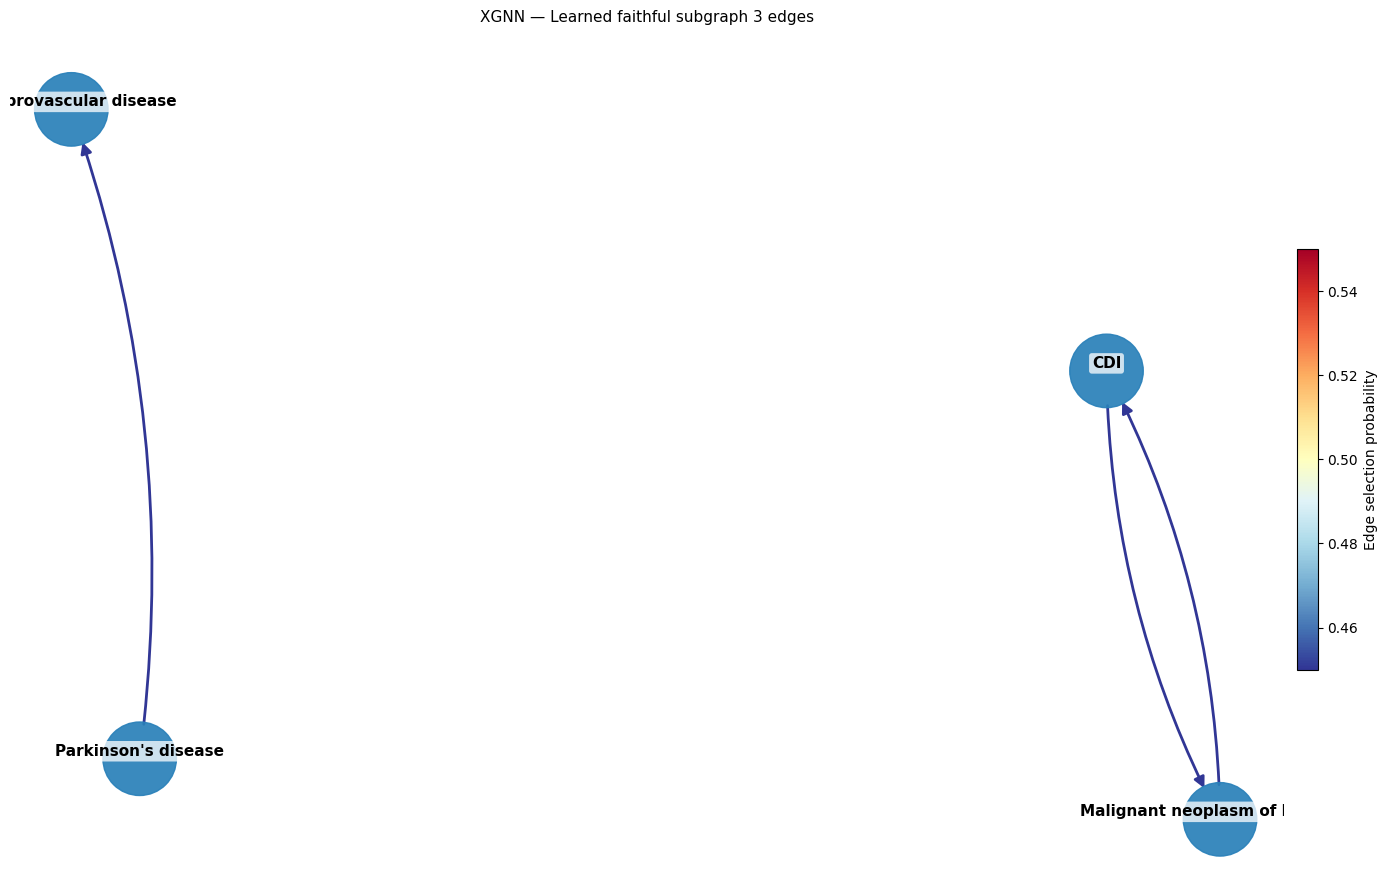

In [87]:
class XGNNExplainer(nn.Module):
    """
    XGNN: Learning to Explain via Contrastive Subgraph Generation.

    Trains a generator network to produce edge masks that preserve the model's
    prediction while minimizing subgraph size. Uses contrastive learning
    between faithful subgraphs and adversarial perturbations.
    """
    def __init__(self, hidden_dim, n_edges, n_layers=2, dropout=0.1):
        super().__init__()
        self.generator = nn.Sequential(
            nn.Linear(2 * hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1),
            nn.Sigmoid(),
        )
        self.temperature = nn.Parameter(torch.tensor(1.0))

    def forward(self, node_emb, edge_index, temperature=1.0):
        """Generate soft edge masks."""
        src_emb = node_emb[edge_index[0]]
        dst_emb = node_emb[edge_index[1]]
        edge_feat = torch.cat([src_emb, dst_emb], dim=-1)
        logits = self.generator(edge_feat).squeeze(-1)
        return torch.sigmoid(logits / temperature)

    def sample_masks(self, node_emb, edge_index, n_samples=10, temperature=1.0):
        """Sample hard masks using Gumbel-Softmax."""
        probs = self.forward(node_emb, edge_index, temperature)
        masks = []
        for _ in range(n_samples):
            u = torch.rand_like(probs)
            hard_mask = (u < probs).float()
            masks.append(hard_mask)
        return masks, probs


def _adaptive_hard_mask(probs, min_keep=5, keep_ratio=0.08, threshold=0.5):
    """Build a robust hard mask; fallback to top-k when thresholding is too sparse."""
    hard_mask = probs > threshold
    if int(hard_mask.sum().item()) < min_keep:
        k = min(max(min_keep, int(round(keep_ratio * probs.numel()))), probs.numel())
        top_idx = torch.topk(probs, k=k, largest=True).indices
        hard_mask = torch.zeros_like(probs, dtype=torch.bool)
        hard_mask[top_idx] = True
    return hard_mask.float()


def train_xgnn_explainer(patient_idx, n_epochs=80, lambda_sparse=0.5, lambda_contrast=0.3):
    """Train XGNN to learn faithful subgraph explanations."""
    c  = C_test[patient_idx].unsqueeze(0).to(DEVICE)
    t  = T_test[patient_idx].unsqueeze(0).to(DEVICE)
    l  = L_test[patient_idx].unsqueeze(0).to(DEVICE)
    pm = PAD_MASK_test[patient_idx].unsqueeze(0).to(DEVICE)
    dm = DEMO_test[patient_idx].unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        node_emb   = model.ontology_enc(EDGE_INDEX).detach()
        logit_orig = model(EDGE_INDEX, c, t, l, pm, dm)
        prob_orig  = torch.sigmoid(logit_orig).detach()

    xgnn = XGNNExplainer(cfg.HIDDEN_DIM, EDGE_INDEX.shape[1], dropout=0.2).to(DEVICE)
    opt  = torch.optim.Adam(xgnn.parameters(), lr=0.01)

    best_fidelity = -float('inf')
    best_masks = None

    # Keep at least a small explanatory subgraph to avoid degenerate all-zero masks.
    min_keep_edges = min(8, max(3, EDGE_INDEX.shape[1] // 20))

    for epoch in range(n_epochs):
        xgnn.train()
        opt.zero_grad()

        # Generate continuous edge probabilities.
        probs = xgnn(node_emb.detach(), EDGE_INDEX,
                     temperature=max(1.0 - epoch / n_epochs, 0.1))
        soft_masks = probs

        # Hard masks for fidelity evaluation with robust fallback.
        hard_masks = _adaptive_hard_mask(
            probs, min_keep=min_keep_edges, keep_ratio=0.08, threshold=0.5
        ).detach()

        # Fidelity loss: preserve prediction with masked subgraph
        if hard_masks.sum() > 0:
            ei_masked = EDGE_INDEX[:, hard_masks > 0.5]
        else:
            ei_masked = EDGE_INDEX

        logit_masked = model(ei_masked, c, t, l, pm, dm)
        prob_masked  = torch.sigmoid(logit_masked)
        fidelity_loss = F.mse_loss(prob_masked, prob_orig)

        # Sparsity regularization
        sparsity_loss = lambda_sparse * probs.mean()

        # Contrastive loss: soft masks stay high on important edges
        contrast_loss = lambda_contrast * F.mse_loss(soft_masks, hard_masks)

        total_loss = fidelity_loss + sparsity_loss + contrast_loss
        total_loss.backward()
        opt.step()

        # Track best configuration
        with torch.no_grad():
            current_fidelity = -abs(prob_masked.item() - prob_orig.item())
            if current_fidelity > best_fidelity:
                best_fidelity = current_fidelity
                best_masks = hard_masks.clone()

    return best_masks.detach().cpu().numpy() if best_masks is not None else None, \
           probs.detach().cpu().numpy()


if len(true_pos_idx) > 0:
    pi_xgnn = true_pos_idx[0]
    hard_masks_xgnn, soft_probs_xgnn = train_xgnn_explainer(pi_xgnn, n_epochs=60)

    if hard_masks_xgnn is not None:
        ei_np = EDGE_INDEX.cpu().numpy()
        rows_xgnn = []
        for i in range(len(hard_masks_xgnn)):
            if i >= ei_np.shape[1]:
                break
            src_c = idx2concept.get(int(ei_np[0, i]))
            dst_c = idx2concept.get(int(ei_np[1, i]))
            if src_c is None or dst_c is None:
                continue
            rows_xgnn.append({
                "source": id2name.get(src_c, str(src_c)),
                "target": id2name.get(dst_c, str(dst_c)),
                "hard_mask": int(hard_masks_xgnn[i]),
                "soft_prob": float(soft_probs_xgnn[i]),
            })

        xgnn_df = pd.DataFrame(rows_xgnn).sort_values("soft_prob", ascending=False)
        n_selected = int(xgnn_df["hard_mask"].sum())
        n_total = len(xgnn_df)
        print(f"XGNN — TP patient {pi_xgnn}: {n_selected}/{n_total} edges selected "
              f"({100*n_selected/n_total:.1f}%)")
        print(xgnn_df[xgnn_df["hard_mask"] == 1].head(10).to_string(index=False))

        sub_xgnn = nx.DiGraph()
        for _, row in xgnn_df[xgnn_df["hard_mask"] == 1].iterrows():
            sub_xgnn.add_edge(row["source"], row["target"], weight=row["soft_prob"])

        if sub_xgnn.number_of_nodes() > 0:
            draw_ontology_graph(
                sub_xgnn,
                title=f"XGNN — Learned faithful subgraph {n_selected} edges",
                colorbar_label="Edge selection probability",
                save_path=PLOTS / "xgnn_faithful_subgraph.png"
            )


## 2G. GNNInterpreter — Neural Interpreter for Node & Edge Scoring

**GNNInterpreter** trains an interpreter MLP to score the importance of each node and edge
based on their contribution to the prediction. Simpler than XGNN, fast inference, 
provides both node and edge importance scores.

GNNInterpreter — TP patient 37 (prob=0.656):
  Top 10 edges by learned importance:
                  source                   target   edge_score
         Unstable angina          Angina pectoris 1.452093e-07
Type 2 diabetes mellitus          Mental disorder 9.353546e-08
  Ischemic heart disease          Angina pectoris 4.246447e-08
              Chest pain          Angina pectoris 3.747012e-08
         Angina pectoris          Unstable angina 3.612702e-08
         Angina pectoris               Chest pain 2.347617e-08
         Angina pectoris   Ischemic heart disease 2.926630e-09
   Myocardial infarction   Ischemic heart disease 2.236214e-09
  Ischemic heart disease    Myocardial infarction 9.411447e-10
         Mental disorder Type 2 diabetes mellitus 8.857272e-10


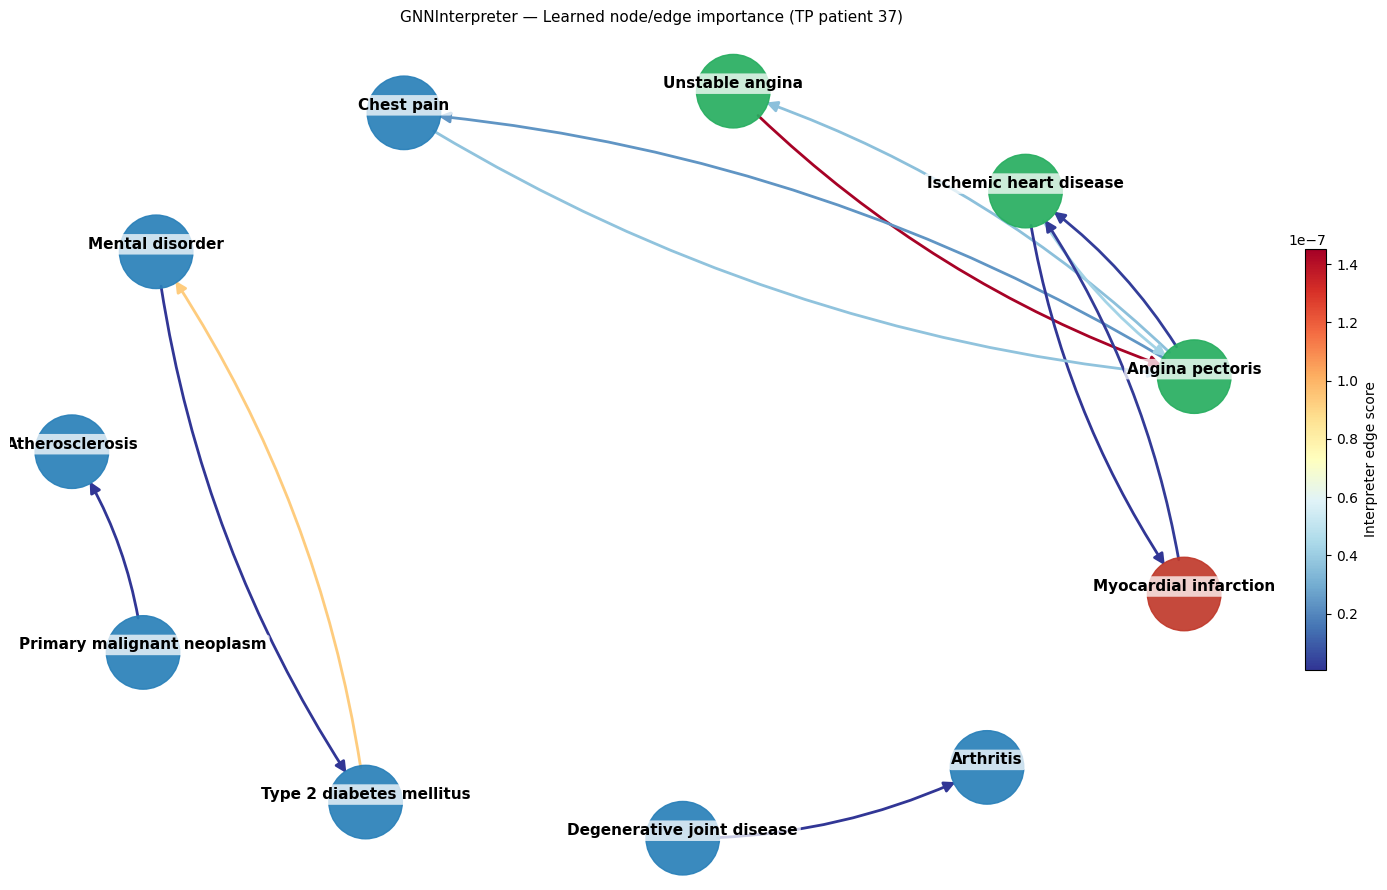

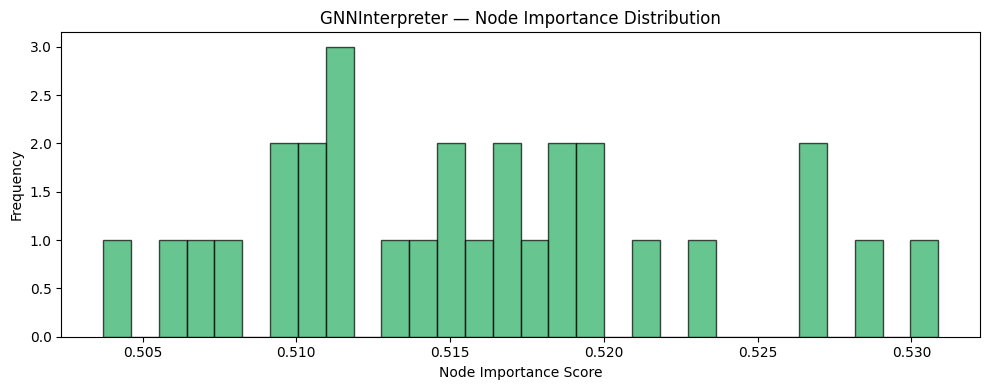

In [88]:
class GNNInterpreter(nn.Module):
    """
    GNNInterpreter: Neural network that learns to score node and edge importance.

    For each node: score = MLP([node_emb, aggregated_neighbor_info])
    For each edge: score = MLP([src_emb, dst_emb, edge_context])

    Training: regression on surrogate importance labels from perturbation-based methods.
    Inference: fast scoring without iterative perturbation.
    """
    def __init__(self, hidden_dim, n_heads=4, dropout=0.1):
        super().__init__()
        # Node importance scorer
        self.node_scorer = nn.Sequential(
            nn.Linear(2 * hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Linear(hidden_dim // 2, 1),
            nn.Sigmoid(),
        )
        # Edge importance scorer
        self.edge_scorer = nn.Sequential(
            nn.Linear(2 * hidden_dim + 32, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Linear(hidden_dim // 2, 1),
            nn.Sigmoid(),
        )
        # Context encoder (learns to extract edge context)
        self.context_enc = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
        )

    def score_nodes(self, node_emb, edge_index):
        """Score importance of each node."""
        n_nodes = node_emb.shape[0]
        neighbor_agg = torch.zeros(n_nodes, node_emb.shape[1], device=node_emb.device)

        for src, dst in zip(edge_index[0], edge_index[1]):
            neighbor_agg[dst] += node_emb[src]

        neighbor_agg = neighbor_agg / (neighbor_agg.norm(dim=-1, keepdim=True) + 1e-8)
        combined = torch.cat([node_emb, neighbor_agg], dim=-1)
        return self.node_scorer(combined).squeeze(-1)

    def score_edges(self, node_emb, edge_index):
        """Score importance of each edge."""
        src_emb = node_emb[edge_index[0]]
        dst_emb = node_emb[edge_index[1]]
        context = self.context_enc(dst_emb)
        combined = torch.cat([src_emb, dst_emb, context], dim=-1)
        return self.edge_scorer(combined).squeeze(-1)


def compute_interpreter_scores(patient_idx, edge_index, use_nodes=True):
    """Compute node and edge importance scores using GNNInterpreter."""
    with torch.no_grad():
        node_emb = model.ontology_enc(edge_index).detach()

    interpreter = GNNInterpreter(cfg.HIDDEN_DIM, dropout=0.1).to(DEVICE)
    opt = torch.optim.Adam(interpreter.parameters(), lr=0.01)

    c  = C_test[patient_idx].unsqueeze(0).to(DEVICE)
    t  = T_test[patient_idx].unsqueeze(0).to(DEVICE)
    l  = L_test[patient_idx].unsqueeze(0).to(DEVICE)
    pm = PAD_MASK_test[patient_idx].unsqueeze(0).to(DEVICE)
    dm = DEMO_test[patient_idx].unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        target_prob = torch.sigmoid(model(edge_index, c, t, l, pm, dm)).item()

    for epoch in range(30):
        opt.zero_grad()
        epoch_loss = 0.0

        n_edges = edge_index.shape[1]
        for _ in range(3):
            edge_scores = interpreter.score_edges(node_emb, edge_index)

            mask = torch.rand(n_edges, device=DEVICE) > 0.5
            if mask.sum() == 0:
                mask[0] = True

            ei_masked = edge_index[:, mask]

            with torch.no_grad():
                masked_prob = torch.sigmoid(model(ei_masked, c, t, l, pm, dm)).item()

            importance_surrogate = abs(masked_prob - target_prob) / (1 - mask.float().mean().item() + 0.1)
            target_tensor = torch.tensor(importance_surrogate, device=DEVICE, dtype=edge_scores.dtype)
            loss = F.mse_loss(edge_scores[mask].mean(), target_tensor)

            epoch_loss = epoch_loss + loss

        epoch_loss.backward()
        opt.step()

    with torch.no_grad():
        node_scores = interpreter.score_nodes(node_emb, edge_index).cpu().numpy()
        edge_scores = interpreter.score_edges(node_emb, edge_index).cpu().numpy()

    return node_scores, edge_scores


if len(true_pos_idx) > 0:
    pi_interp = true_pos_idx[0]
    node_scores, edge_scores = compute_interpreter_scores(pi_interp, EDGE_INDEX)

    ei_np = EDGE_INDEX.cpu().numpy()
    rows_interp = []

    for i in range(len(edge_scores)):
        if i >= ei_np.shape[1]:
            break
        src_c = idx2concept.get(int(ei_np[0, i]))
        dst_c = idx2concept.get(int(ei_np[1, i]))
        if src_c is None or dst_c is None:
            continue
        rows_interp.append({
            "source": id2name.get(src_c, str(src_c)),
            "target": id2name.get(dst_c, str(dst_c)),
            "edge_score": float(edge_scores[i]),
        })

    interp_df = pd.DataFrame(rows_interp).sort_values("edge_score", ascending=False)
    print(f"GNNInterpreter — TP patient {pi_interp} (prob={probs_test[pi_interp]:.3f}):")
    print(f"  Top {min(10, len(interp_df))} edges by learned importance:")
    print(interp_df.head(10).to_string(index=False))

    # Visualize top edges
    sub_interp = nx.DiGraph()
    for _, row in interp_df.head(12).iterrows():
        sub_interp.add_edge(row["source"], row["target"], weight=row["edge_score"])

    if sub_interp.number_of_nodes() > 0:
        draw_ontology_graph(sub_interp,
            title=f"GNNInterpreter — Learned node/edge importance (TP patient {pi_interp})",
            colorbar_label="Interpreter edge score",
            save_path=PLOTS / "gnninterpreter_tp.png")

    # Also show node importance distribution
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(node_scores, bins=30, color="#27ae60", alpha=0.7, edgecolor="black")
    ax.set_xlabel("Node Importance Score")
    ax.set_ylabel("Frequency")
    ax.set_title("GNNInterpreter — Node Importance Distribution")
    plt.tight_layout()
    plt.savefig(PLOTS / "gnninterpreter_node_scores.png", dpi=220, bbox_inches="tight")
    plt.show()


## 2H. GFlowExplainer — Generative Flow Sampling for Explanations

**GFlowExplainer** models explanation generation as a sequential flow process.
At each step, selects nodes/edges to include based on learned policy.
Rewards model fidelity. Produces diverse, high-quality explanatory subgraphs via importance sampling.

GFlowExplainer — TP patient 37 (prob=0.656)
  Best rollout reward: 1.9916
  Rollout reward stats: μ=1.9056, σ=0.0543
  Selected 8 edges
    Parkinson's disease                      → Cerebrovascular disease                 
    Mental disorder                          → Type 2 diabetes mellitus                
    Akinesia                                 → Parkinson's disease                     
    Angina pectoris                          → Chest pain                              
    Atherosclerosis                          → Primary malignant neoplasm              
    Unstable angina                          → Angina pectoris                         
    Cerebral infarction                      → Congestive heart failure                
    Vascular dementia                        → Arthritis                               


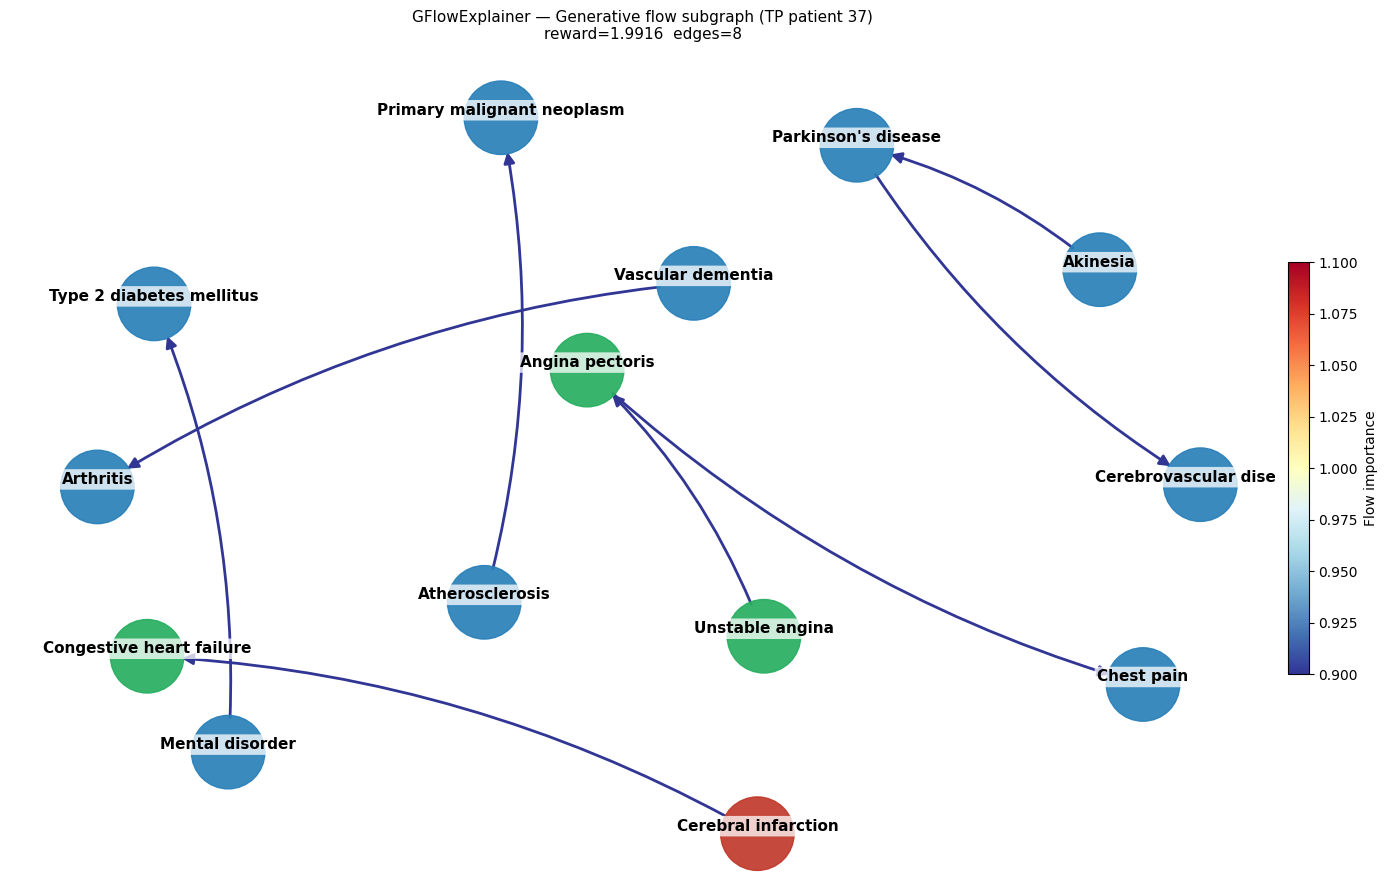

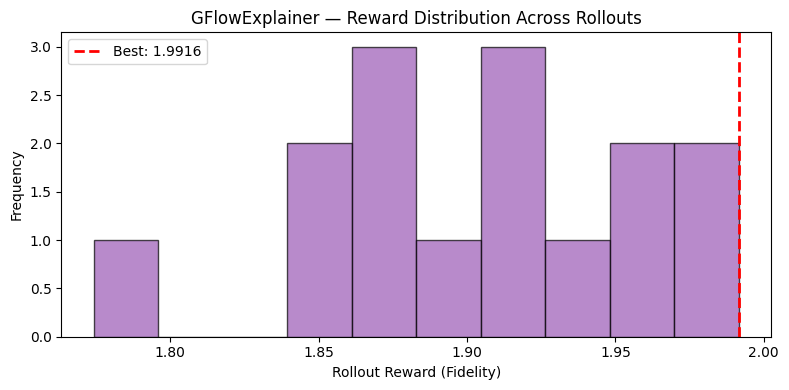

In [89]:
class GFlowExplainerPolicy(nn.Module):
    """
    GFlow policy: learns to sequentially select edges to include in explanation.
    At each step, outputs probability over remaining edges.
    Training: maximize reward (fidelity) via policy gradient.
    """
    def __init__(self, hidden_dim, max_steps=10):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.max_steps = max_steps
        self.embedding_context = nn.Linear(2 * hidden_dim, hidden_dim)
        self.step_encoder = nn.Embedding(max_steps, hidden_dim)
        self.policy_head = nn.Sequential(
            nn.Linear(3 * hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, node_emb, edge_index, selected_set, step):
        """
        Compute log-probabilities for selecting each remaining edge.
        selected_set: set of already-selected edge indices
        """
        n_edges = edge_index.shape[1]
        logits = []

        for edge_idx in range(n_edges):
            if edge_idx in selected_set:
                logits.append(torch.tensor(-1e9, device=node_emb.device, dtype=node_emb.dtype))
            else:
                src_emb = node_emb[edge_index[0, edge_idx]]
                dst_emb = node_emb[edge_index[1, edge_idx]]
                edge_context = torch.cat([src_emb, dst_emb], dim=-1)

                step_emb = self.step_encoder(torch.tensor(min(step, self.max_steps - 1),
                                                           device=node_emb.device))
                combined = torch.cat([edge_context, step_emb], dim=-1)
                logit = self.policy_head(combined).squeeze()
                logits.append(logit)

        logits = torch.stack(logits)
        return F.log_softmax(logits, dim=0)


@torch.no_grad()
def gflow_explain(patient_idx, max_steps=8, n_rollouts=20, seed=42):
    """
    GFlowExplainer: sample diverse and high-reward explanatory subgraphs.
    Reward = preservation of prediction probability when using selected edges.
    """
    c  = C_test[patient_idx].unsqueeze(0).to(DEVICE)
    t  = T_test[patient_idx].unsqueeze(0).to(DEVICE)
    l  = L_test[patient_idx].unsqueeze(0).to(DEVICE)
    pm = PAD_MASK_test[patient_idx].unsqueeze(0).to(DEVICE)
    dm = DEMO_test[patient_idx].unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logit_full = model(EDGE_INDEX, c, t, l, pm, dm)
        prob_full = torch.sigmoid(logit_full).item()

    node_emb = model.ontology_enc(EDGE_INDEX).detach()
    policy = GFlowExplainerPolicy(cfg.HIDDEN_DIM, max_steps=max_steps).to(DEVICE)
    policy.eval()

    rng = np.random.RandomState(seed)
    rollout_rewards = []
    rollout_subgraphs = []

    for _ in range(n_rollouts):
        selected_edges = set()
        trajectory_logprobs = []

        for step in range(max_steps):
            log_probs = policy(node_emb, EDGE_INDEX, selected_edges, step)
            valid_idx = [i for i in range(len(log_probs)) if i not in selected_edges]

            if not valid_idx:
                break

            # Sample from policy
            probs = torch.exp(log_probs[valid_idx])
            probs = probs / probs.sum()
            choice_idx = rng.choice(len(valid_idx), p=probs.cpu().numpy())
            selected_edge_idx = valid_idx[choice_idx]

            selected_edges.add(selected_edge_idx)
            trajectory_logprobs.append(log_probs[selected_edge_idx])

            # Compute reward after each step
            if len(selected_edges) > 0:
                mask = torch.zeros(EDGE_INDEX.shape[1], dtype=torch.bool, device=DEVICE)
                for eidx in selected_edges:
                    mask[eidx] = True
                ei_sub = EDGE_INDEX[:, mask]

                if ei_sub.shape[1] > 0:
                    with torch.no_grad():
                        prob_sub = torch.sigmoid(model(ei_sub, c, t, l, pm, dm)).item()
                    reward = 1.0 - abs(prob_sub - prob_full)  # Fidelity reward
                else:
                    reward = 0.0
            else:
                reward = 0.0

        # Terminal reward
        if len(selected_edges) > 0:
            mask = torch.zeros(EDGE_INDEX.shape[1], dtype=torch.bool, device=DEVICE)
            for eidx in selected_edges:
                mask[eidx] = True
            ei_sub = EDGE_INDEX[:, mask]

            if ei_sub.shape[1] > 0:
                with torch.no_grad():
                    prob_terminal = torch.sigmoid(model(ei_sub, c, t, l, pm, dm)).item()
                reward = 2.0 * (1.0 - abs(prob_terminal - prob_full))  # Higher weight for terminal
            else:
                reward = 0.0
        else:
            reward = 0.0

        rollout_rewards.append(reward)
        rollout_subgraphs.append(selected_edges.copy())

    # Select top rollout
    best_idx = np.argmax(rollout_rewards)
    best_subgraph = rollout_subgraphs[best_idx]
    best_reward = rollout_rewards[best_idx]

    return best_subgraph, best_reward, rollout_rewards


if len(true_pos_idx) > 0:
    pi_gflow = true_pos_idx[0]
    best_sg, best_rew, all_rews = gflow_explain(pi_gflow, max_steps=8, n_rollouts=15)

    ei_np = EDGE_INDEX.cpu().numpy()
    gflow_graph = nx.DiGraph()

    print(f"GFlowExplainer — TP patient {pi_gflow} (prob={probs_test[pi_gflow]:.3f})")
    print(f"  Best rollout reward: {best_rew:.4f}")
    print(f"  Rollout reward stats: μ={np.mean(all_rews):.4f}, σ={np.std(all_rews):.4f}")
    print(f"  Selected {len(best_sg)} edges")

    edge_count = 0
    for edge_idx in best_sg:
        if edge_idx >= ei_np.shape[1]:
            continue
        src_idx = int(ei_np[0, edge_idx])
        dst_idx = int(ei_np[1, edge_idx])
        src_c = idx2concept.get(src_idx)
        dst_c = idx2concept.get(dst_idx)
        if src_c is None or dst_c is None:
            continue
        src_name = id2name.get(src_c, str(src_c))
        dst_name = id2name.get(dst_c, str(dst_c))
        gflow_graph.add_edge(src_name, dst_name, weight=1.0)
        edge_count += 1
        if edge_count <= 10:
            print(f"    {src_name:40s} → {dst_name:40s}")

    if gflow_graph.number_of_nodes() > 0:
        draw_ontology_graph(gflow_graph,
            title=f"GFlowExplainer — Generative flow subgraph (TP patient {pi_gflow})\n"
                  f"reward={best_rew:.4f}  edges={len(best_sg)}",
            colorbar_label="Flow importance",
            save_path=PLOTS / "gflow_explainer_tp.png")

    # Show reward distribution
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(all_rews, bins=10, color="#9b59b6", alpha=0.7, edgecolor="black")
    ax.axvline(best_rew, color="red", lw=2, linestyle="--", label=f"Best: {best_rew:.4f}")
    ax.set_xlabel("Rollout Reward (Fidelity)")
    ax.set_ylabel("Frequency")
    ax.set_title("GFlowExplainer — Reward Distribution Across Rollouts")
    ax.legend()
    plt.tight_layout()
    plt.savefig(PLOTS / "gflow_reward_dist.png", dpi=220, bbox_inches="tight")
    plt.show()


## 2I. GSAT — Information Bottleneck Subgraph Attribution

**GSAT** learns an information-constrained mask over graph structure.
The objective keeps prediction fidelity while minimizing mutual information
between explanation mask and input graph (sparsity + entropy regularization).

GSAT — TP patient 37: 5/42 edges selected (11.9%)
                        source                         target  hard_mask        score
                           CDI Malignant neoplasm of bronchus       True 6.997230e-12
Malignant neoplasm of bronchus                            CDI       True 5.232482e-12
               Angina pectoris                     Chest pain       True 2.443269e-12
                    Chest pain                Angina pectoris       True 1.303686e-12
               Unstable angina                Angina pectoris       True 8.415671e-13


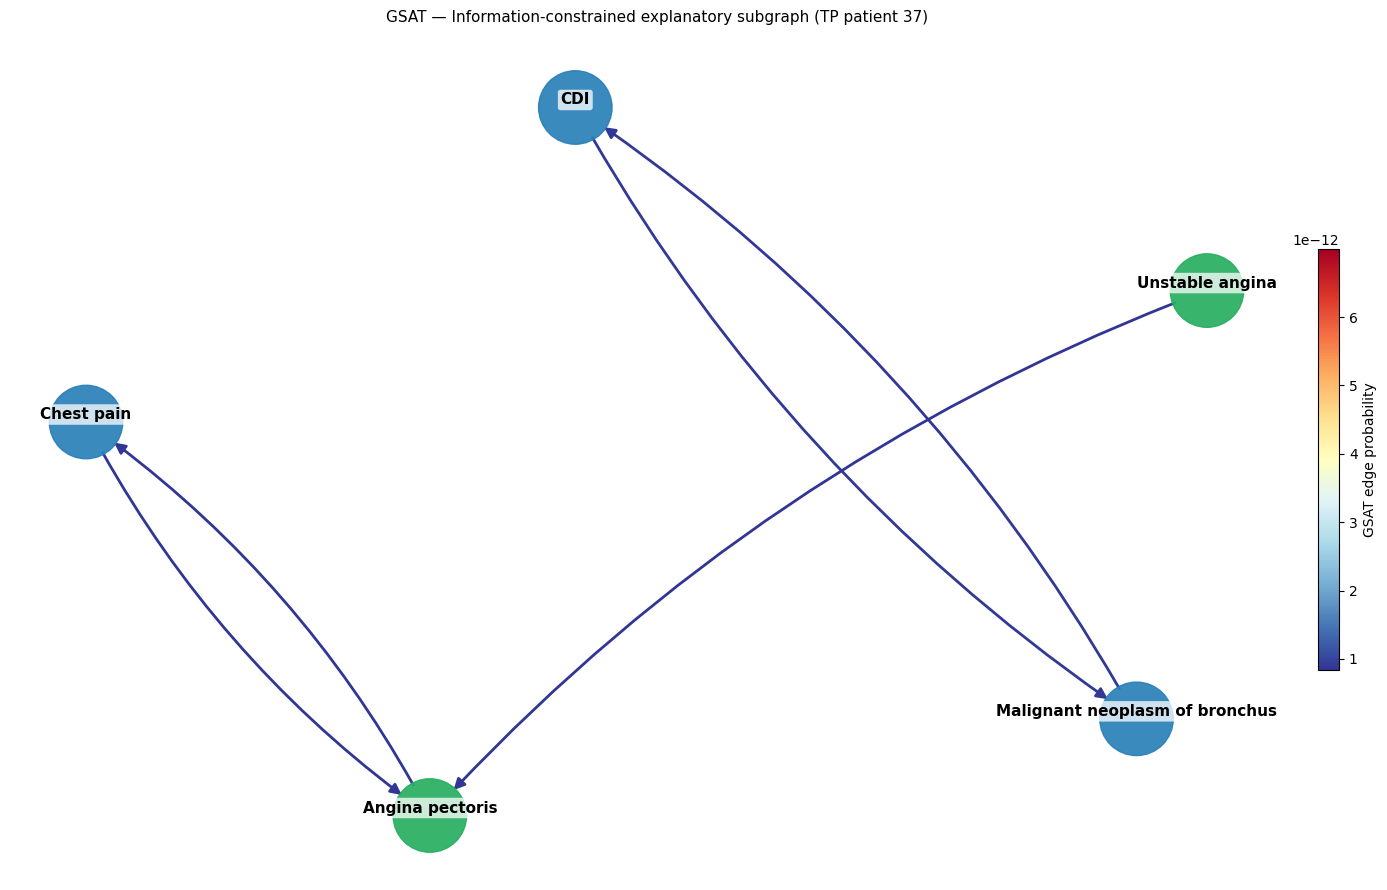

In [90]:
class GSATExplainer(nn.Module):
    """
    GSAT-style explainer with information bottleneck regularization.

    This implementation learns soft edge gates and projects them to node-level
    relevance, then perturbs concept embeddings through x_override.
    """
    def __init__(self, hidden_dim):
        super().__init__()
        self.edge_gate = nn.Sequential(
            nn.Linear(2 * hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def edge_probs(self, node_emb, edge_index):
        src_emb = node_emb[edge_index[0]]
        dst_emb = node_emb[edge_index[1]]
        logits = self.edge_gate(torch.cat([src_emb, dst_emb], dim=-1)).squeeze(-1)
        return torch.sigmoid(logits)


def _edge_to_node_scores(edge_probs, edge_index, n_nodes):
    node_scores = torch.zeros(n_nodes, device=edge_probs.device)
    node_counts = torch.zeros(n_nodes, device=edge_probs.device)

    src_idx = edge_index[0]
    dst_idx = edge_index[1]
    ones = torch.ones_like(edge_probs)

    node_scores.index_add_(0, src_idx, edge_probs)
    node_scores.index_add_(0, dst_idx, edge_probs)
    node_counts.index_add_(0, src_idx, ones)
    node_counts.index_add_(0, dst_idx, ones)

    node_scores = node_scores / (node_counts + 1e-9)
    return node_scores.clamp(0.0, 1.0)


def train_gsat_explainer(patient_idx, n_epochs=80, lambda_sparse=0.05, lambda_info=0.02):
    c  = C_test[patient_idx].unsqueeze(0).to(DEVICE)
    t  = T_test[patient_idx].unsqueeze(0).to(DEVICE)
    l  = L_test[patient_idx].unsqueeze(0).to(DEVICE)
    pm = PAD_MASK_test[patient_idx].unsqueeze(0).to(DEVICE)
    dm = DEMO_test[patient_idx].unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logit_orig = model(EDGE_INDEX, c, t, l, pm, dm)
        prob_orig = torch.sigmoid(logit_orig).detach()
        node_emb_detached = model.ontology_enc(EDGE_INDEX).detach()

    # Clone to avoid inference-tensor autograd restrictions.
    base_embeddings = CONCEPT_EMBEDDINGS_RAW.detach().clone()

    gsat = GSATExplainer(cfg.HIDDEN_DIM).to(DEVICE)
    opt = torch.optim.Adam(gsat.parameters(), lr=0.01)

    best_obj = float("inf")
    best_edge_probs = None

    for _ in range(n_epochs):
        opt.zero_grad()

        e_probs = gsat.edge_probs(node_emb_detached, EDGE_INDEX)
        n_scores = _edge_to_node_scores(e_probs, EDGE_INDEX, NUM_CONCEPTS)

        # Gate raw concept embeddings using learned node relevance.
        x_override = base_embeddings * n_scores.unsqueeze(-1)

        logit_masked = model(EDGE_INDEX, c, t, l, pm, dm, x_override=x_override)
        prob_masked = torch.sigmoid(logit_masked)

        fidelity_loss = F.mse_loss(prob_masked, prob_orig)
        sparsity_loss = e_probs.mean()

        # Information bottleneck style entropy regularizer.
        ent = -e_probs * torch.log(e_probs + 1e-9) - (1 - e_probs) * torch.log(1 - e_probs + 1e-9)
        info_loss = ent.mean()

        total_loss = fidelity_loss + lambda_sparse * sparsity_loss + lambda_info * info_loss
        total_loss.backward()
        opt.step()

        val = float(total_loss.item())
        if val < best_obj:
            best_obj = val
            best_edge_probs = e_probs.detach().clone()

    if best_edge_probs is None:
        return None

    edge_probs_np = best_edge_probs.cpu().numpy()
    threshold = float(np.quantile(edge_probs_np, 0.90))
    hard_mask = edge_probs_np >= threshold

    # Ensure non-empty explanatory set.
    if hard_mask.sum() < 3:
        k = min(8, len(edge_probs_np))
        top_idx = np.argsort(-edge_probs_np)[:k]
        hard_mask = np.zeros_like(edge_probs_np, dtype=bool)
        hard_mask[top_idx] = True

    return hard_mask, edge_probs_np


if len(true_pos_idx) > 0:
    pi_gsat = int(true_pos_idx[0])
    gsat_hard, gsat_probs = train_gsat_explainer(pi_gsat, n_epochs=60)

    if gsat_hard is not None:
        ei_np = EDGE_INDEX.cpu().numpy()
        rows_gsat = []

        for i in range(len(gsat_probs)):
            if i >= ei_np.shape[1]:
                break
            src_c = idx2concept.get(int(ei_np[0, i]))
            dst_c = idx2concept.get(int(ei_np[1, i]))
            if src_c is None or dst_c is None:
                continue
            rows_gsat.append({
                "source": id2name.get(src_c, str(src_c)),
                "target": id2name.get(dst_c, str(dst_c)),
                "hard_mask": bool(gsat_hard[i]),
                "score": float(gsat_probs[i]),
            })

        gsat_df = pd.DataFrame(rows_gsat).sort_values("score", ascending=False)
        n_sel = int(gsat_df["hard_mask"].sum())
        n_tot = len(gsat_df)

        print(f"GSAT — TP patient {pi_gsat}: {n_sel}/{n_tot} edges selected ({100*n_sel/max(n_tot,1):.1f}%)")
        print(gsat_df[gsat_df["hard_mask"]].head(10).to_string(index=False))

        sub_gsat = nx.DiGraph()
        for _, row in gsat_df[gsat_df["hard_mask"]].iterrows():
            sub_gsat.add_edge(row["source"], row["target"], weight=row["score"])

        if sub_gsat.number_of_nodes() > 0:
            draw_ontology_graph(
                sub_gsat,
                title=f"GSAT — Information-constrained explanatory subgraph (TP patient {pi_gsat})",
                colorbar_label="GSAT edge probability",
                save_path=PLOTS / "gsat_tp.png",
            )

## 2J. GraphSVX — Local Surrogate Explanations

**GraphSVX** fits a local surrogate around one patient by perturbing concept presence.
The surrogate coefficients approximate each concept's local contribution to the prediction.

In [91]:
from sklearn.linear_model import Ridge


def graphsvx_explain(patient_idx, n_samples=120, alpha=1.0, seed=42):
    c_seq = C_test[patient_idx].cpu().numpy()
    pm_seq = PAD_MASK_test[patient_idx].cpu().numpy()

    present = sorted({int(cidx) for cidx, is_pad in zip(c_seq, pm_seq)
                      if (not is_pad) and int(cidx) < NUM_CONCEPTS})
    if len(present) == 0:
        return pd.DataFrame(columns=["concept", "importance"])

    c  = C_test[patient_idx].unsqueeze(0).to(DEVICE)
    t  = T_test[patient_idx].unsqueeze(0).to(DEVICE)
    l  = L_test[patient_idx].unsqueeze(0).to(DEVICE)
    pm = PAD_MASK_test[patient_idx].unsqueeze(0).to(DEVICE)
    dm = DEMO_test[patient_idx].unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        base_prob = float(torch.sigmoid(model(EDGE_INDEX, c, t, l, pm, dm)).item())

    rng = np.random.RandomState(seed + int(patient_idx))
    m = len(present)
    X = np.zeros((n_samples, m), dtype=np.float32)
    y = np.zeros(n_samples, dtype=np.float32)

    for i in range(n_samples):
        z = (rng.rand(m) > 0.5).astype(np.float32)
        if z.sum() == 0:
            z[rng.randint(0, m)] = 1.0

        keep_concepts = {present[j] for j in range(m) if z[j] > 0.5}
        c_masked = C_test[patient_idx].clone()

        for pos in range(len(c_masked)):
            cidx = int(c_masked[pos].item())
            if cidx != PAD_IDX and cidx not in keep_concepts:
                c_masked[pos] = PAD_IDX

        c_m = c_masked.unsqueeze(0).to(DEVICE)
        t_m = T_test[patient_idx].unsqueeze(0).to(DEVICE)
        l_m = L_test[patient_idx].unsqueeze(0).to(DEVICE)
        pm_m = (c_masked == PAD_IDX).unsqueeze(0).to(DEVICE)
        dm_m = DEMO_test[patient_idx].unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            y[i] = float(torch.sigmoid(model(EDGE_INDEX, c_m, t_m, l_m, pm_m, dm_m)).item())

        X[i] = z

    reg = Ridge(alpha=alpha, fit_intercept=True)
    reg.fit(X, y)

    coefs = np.abs(reg.coef_)

    # Fallback for near-constant local responses: use leave-one-concept-out deltas.
    if float(coefs.max()) < 1e-8:
        loo = np.zeros(m, dtype=np.float32)
        for j, cidx_drop in enumerate(present):
            keep = set(present)
            keep.discard(cidx_drop)

            c_masked = C_test[patient_idx].clone()
            for pos in range(len(c_masked)):
                cidx = int(c_masked[pos].item())
                if cidx != PAD_IDX and cidx not in keep:
                    c_masked[pos] = PAD_IDX

            c_m = c_masked.unsqueeze(0).to(DEVICE)
            t_m = T_test[patient_idx].unsqueeze(0).to(DEVICE)
            l_m = L_test[patient_idx].unsqueeze(0).to(DEVICE)
            pm_m = (c_masked == PAD_IDX).unsqueeze(0).to(DEVICE)
            dm_m = DEMO_test[patient_idx].unsqueeze(0).to(DEVICE)

            with torch.no_grad():
                p_drop = float(torch.sigmoid(model(EDGE_INDEX, c_m, t_m, l_m, pm_m, dm_m)).item())
            loo[j] = abs(base_prob - p_drop)

        coefs = loo

    rows = []
    for j, cidx in enumerate(present):
        cid = idx2concept.get(cidx)
        rows.append({
            "concept_idx": cidx,
            "concept": id2name.get(cid, str(cid)),
            "importance": float(coefs[j]),
        })

    df = pd.DataFrame(rows).sort_values("importance", ascending=False)

    print(f"GraphSVX — TP patient {patient_idx} (base prob={base_prob:.3f})")
    print(df.head(12).to_string(index=False))

    top_nodes = set(df.head(min(8, len(df)))["concept"].tolist())
    ei_np = EDGE_INDEX.cpu().numpy()
    sub_sx = nx.DiGraph()
    for edge_i in range(ei_np.shape[1]):
        src_c = idx2concept.get(int(ei_np[0, edge_i]))
        dst_c = idx2concept.get(int(ei_np[1, edge_i]))
        if src_c is None or dst_c is None:
            continue
        src_name = id2name.get(src_c, str(src_c))
        dst_name = id2name.get(dst_c, str(dst_c))
        if src_name in top_nodes and dst_name in top_nodes:
            sub_sx.add_edge(src_name, dst_name, weight=1.0)

    if sub_sx.number_of_nodes() > 0:
        draw_ontology_graph(
            sub_sx,
            title=f"GraphSVX — surrogate concept subgraph (TP patient {patient_idx})",
            colorbar_label="Surrogate support",
            save_path=PLOTS / "graphsvx_tp.png",
        )

    return df


if len(true_pos_idx) > 0:
    pi_sx = int(true_pos_idx[0])
    graphsvx_df = graphsvx_explain(pi_sx, n_samples=96, alpha=1.0)

GraphSVX — TP patient 37 (base prob=0.603)
 concept_idx   concept  importance
          23 Arthritis    0.022143


## 4. Compact Benchmark (Runtime, Fidelity, Sparsity)

Single-patient benchmark for quick comparison across explainers.
- **Runtime (ms)**: wall-clock time to generate one explanation
- **Fidelity**: $1 - |p_{explained} - p_{full}|$
- **Sparsity**: $1 - \frac{|E_{selected}|}{|E|}$ (edge methods) or concept analogue for GraphSVX

GraphSVX — TP patient 37 (base prob=0.635)
 concept_idx   concept  importance
          23 Arthritis    0.018035
Benchmark patient: 37  base_prob=0.6041
        method   scope  runtime_ms  fidelity  sparsity
          GSAT    edge    254.8916    0.9989    0.8810
GFlowExplainer    edge   1110.0977    0.9977    0.8095
     GraphMASK    edge    128.0788    0.9706    0.8810
   PGExplainer    edge      7.2010    0.9461    0.9048
      GraphSVX concept    242.7726    0.9319    0.0000
          XGNN    edge    207.9720    0.9305    0.9286
GNNInterpreter    edge    388.2694    0.9295    0.9048


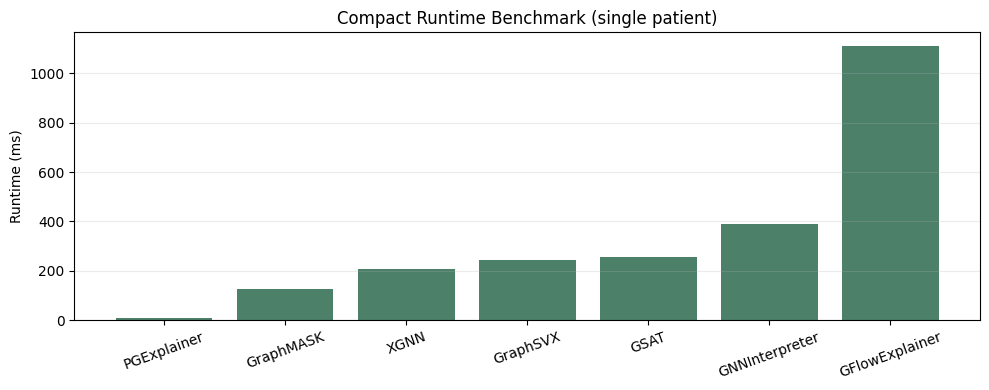

In [92]:
import time


def _patient_batch(pi):
    return (
        C_test[pi].unsqueeze(0).to(DEVICE),
        T_test[pi].unsqueeze(0).to(DEVICE),
        L_test[pi].unsqueeze(0).to(DEVICE),
        PAD_MASK_test[pi].unsqueeze(0).to(DEVICE),
        DEMO_test[pi].unsqueeze(0).to(DEVICE),
    )


@torch.no_grad()
def _prob_from_edge_mask(patient_idx, edge_mask_bool):
    c, t, l, pm, dm = _patient_batch(patient_idx)
    if edge_mask_bool.sum() == 0:
        ei = EDGE_INDEX
    else:
        ei = EDGE_INDEX[:, edge_mask_bool]
    return float(torch.sigmoid(model(ei, c, t, l, pm, dm)).item())


@torch.no_grad()
def _prob_from_concept_set(patient_idx, keep_concepts):
    c_masked = C_test[patient_idx].clone()
    for pos in range(len(c_masked)):
        cidx = int(c_masked[pos].item())
        if cidx != PAD_IDX and cidx not in keep_concepts:
            c_masked[pos] = PAD_IDX

    c_m = c_masked.unsqueeze(0).to(DEVICE)
    t_m = T_test[patient_idx].unsqueeze(0).to(DEVICE)
    l_m = L_test[patient_idx].unsqueeze(0).to(DEVICE)
    pm_m = (c_masked == PAD_IDX).unsqueeze(0).to(DEVICE)
    dm_m = DEMO_test[patient_idx].unsqueeze(0).to(DEVICE)
    return float(torch.sigmoid(model(EDGE_INDEX, c_m, t_m, l_m, pm_m, dm_m)).item())


if len(true_pos_idx) > 0:
    pi_bench = int(true_pos_idx[0])
    base_prob = predict_prob_single(pi_bench)
    n_edges_total = EDGE_INDEX.shape[1]

    rows = []

    # PGExplainer
    try:
        t0 = time.perf_counter()
        c_pi = C_test[pi_bench].to(DEVICE)
        t_pi = T_test[pi_bench].to(DEVICE)
        l_pi = L_test[pi_bench].to(DEVICE)
        pm_pi = PAD_MASK_test[pi_bench].to(DEVICE)
        dm_pi = DEMO_test[pi_bench].to(DEVICE)
        pg_wrapper.set_patient(c_pi, t_pi, l_pi, pm_pi, dm_pi)

        x_input = CONCEPT_EMBEDDINGS_RAW.clone().to(DEVICE)
        y_target = torch.tensor([1 if probs_test[pi_bench] >= BEST_THR else 0], device=DEVICE)
        explanation = pg_explainer(x=x_input, edge_index=EDGE_INDEX, target=y_target)

        edge_scores = explanation.edge_mask.detach().cpu().numpy()
        k = max(3, int(0.10 * len(edge_scores)))
        keep = np.argsort(-edge_scores)[:k]
        mask = np.zeros_like(edge_scores, dtype=bool)
        mask[keep] = True
        p_exp = _prob_from_edge_mask(pi_bench, torch.tensor(mask, device=DEVICE))
        dt = (time.perf_counter() - t0) * 1000.0
        rows.append({"method": "PGExplainer", "scope": "edge", "runtime_ms": dt,
                     "fidelity": 1.0 - abs(p_exp - base_prob), "sparsity": 1.0 - (mask.sum() / max(len(mask), 1))})
    except Exception as e:
        print(f"[benchmark] PGExplainer skipped: {e}")

    # GraphMASK
    try:
        t0 = time.perf_counter()
        gates = train_graphmask(pi_bench, n_epochs=20, lambda_sparse=0.5)
        mask = gates > np.quantile(gates, 0.90)
        if mask.sum() < 3:
            top_idx = np.argsort(-gates)[:min(8, len(gates))]
            mask = np.zeros_like(gates, dtype=bool)
            mask[top_idx] = True
        p_exp = _prob_from_edge_mask(pi_bench, torch.tensor(mask, device=DEVICE))
        dt = (time.perf_counter() - t0) * 1000.0
        rows.append({"method": "GraphMASK", "scope": "edge", "runtime_ms": dt,
                     "fidelity": 1.0 - abs(p_exp - base_prob), "sparsity": 1.0 - (mask.sum() / max(len(mask), 1))})
    except Exception as e:
        print(f"[benchmark] GraphMASK skipped: {e}")

    # XGNN
    try:
        t0 = time.perf_counter()
        hard, _ = train_xgnn_explainer(pi_bench, n_epochs=30)
        mask = hard.astype(bool)
        p_exp = _prob_from_edge_mask(pi_bench, torch.tensor(mask, device=DEVICE))
        dt = (time.perf_counter() - t0) * 1000.0
        rows.append({"method": "XGNN", "scope": "edge", "runtime_ms": dt,
                     "fidelity": 1.0 - abs(p_exp - base_prob), "sparsity": 1.0 - (mask.sum() / max(len(mask), 1))})
    except Exception as e:
        print(f"[benchmark] XGNN skipped: {e}")

    # GNNInterpreter
    try:
        t0 = time.perf_counter()
        _, e_scores = compute_interpreter_scores(pi_bench, EDGE_INDEX)
        k = max(3, int(0.10 * len(e_scores)))
        keep = np.argsort(-e_scores)[:k]
        mask = np.zeros_like(e_scores, dtype=bool)
        mask[keep] = True
        p_exp = _prob_from_edge_mask(pi_bench, torch.tensor(mask, device=DEVICE))
        dt = (time.perf_counter() - t0) * 1000.0
        rows.append({"method": "GNNInterpreter", "scope": "edge", "runtime_ms": dt,
                     "fidelity": 1.0 - abs(p_exp - base_prob), "sparsity": 1.0 - (mask.sum() / max(len(mask), 1))})
    except Exception as e:
        print(f"[benchmark] GNNInterpreter skipped: {e}")

    # GFlowExplainer
    try:
        t0 = time.perf_counter()
        best_sg, _, _ = gflow_explain(pi_bench, max_steps=8, n_rollouts=12)
        mask = np.zeros(n_edges_total, dtype=bool)
        for eidx in best_sg:
            if 0 <= int(eidx) < n_edges_total:
                mask[int(eidx)] = True
        p_exp = _prob_from_edge_mask(pi_bench, torch.tensor(mask, device=DEVICE))
        dt = (time.perf_counter() - t0) * 1000.0
        rows.append({"method": "GFlowExplainer", "scope": "edge", "runtime_ms": dt,
                     "fidelity": 1.0 - abs(p_exp - base_prob), "sparsity": 1.0 - (mask.sum() / max(len(mask), 1))})
    except Exception as e:
        print(f"[benchmark] GFlowExplainer skipped: {e}")

    # GSAT
    try:
        t0 = time.perf_counter()
        hard, _ = train_gsat_explainer(pi_bench, n_epochs=40)
        mask = hard.astype(bool)
        p_exp = _prob_from_edge_mask(pi_bench, torch.tensor(mask, device=DEVICE))
        dt = (time.perf_counter() - t0) * 1000.0
        rows.append({"method": "GSAT", "scope": "edge", "runtime_ms": dt,
                     "fidelity": 1.0 - abs(p_exp - base_prob), "sparsity": 1.0 - (mask.sum() / max(len(mask), 1))})
    except Exception as e:
        print(f"[benchmark] GSAT skipped: {e}")

    # GraphSVX (concept-space surrogate)
    try:
        t0 = time.perf_counter()
        sx_df = graphsvx_explain(pi_bench, n_samples=96, alpha=1.0, seed=123)
        top_k = min(5, len(sx_df))
        keep_concepts = set(sx_df.head(top_k)["concept_idx"].astype(int).tolist())
        unique_present = sorted({int(cidx) for cidx, is_pad in zip(C_test[pi_bench].cpu().numpy(), PAD_MASK_test[pi_bench].cpu().numpy())
                                 if (not is_pad) and int(cidx) < NUM_CONCEPTS})
        p_exp = _prob_from_concept_set(pi_bench, keep_concepts)
        dt = (time.perf_counter() - t0) * 1000.0
        sparsity = 1.0 - (len(keep_concepts) / max(len(unique_present), 1))
        rows.append({"method": "GraphSVX", "scope": "concept", "runtime_ms": dt,
                     "fidelity": 1.0 - abs(p_exp - base_prob), "sparsity": sparsity})
    except Exception as e:
        print(f"[benchmark] GraphSVX skipped: {e}")

    benchmark_df = pd.DataFrame(rows).sort_values(["fidelity", "sparsity"], ascending=[False, False])
    print(f"Benchmark patient: {pi_bench}  base_prob={base_prob:.4f}")
    print(benchmark_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

    fig, ax = plt.subplots(figsize=(10, 4))
    show_df = benchmark_df.sort_values("runtime_ms", ascending=True)
    ax.bar(show_df["method"], show_df["runtime_ms"], color="#2d6a4f", alpha=0.85)
    ax.set_ylabel("Runtime (ms)")
    ax.set_title("Compact Runtime Benchmark (single patient)")
    ax.grid(alpha=0.25, axis="y")
    ax.tick_params(axis="x", rotation=20)
    plt.tight_layout()
    plt.savefig(PLOTS / "compact_benchmark_runtime.png", dpi=220, bbox_inches="tight")
    plt.show()

## 4. Method Resume

### Factual explainers
- **PGExplainer**: learned edge masking for fast local explanations.
- **GraphMASK**: sparse differentiable gates with strong fidelity-sparsity trade-off.
- **GNN-LRP**: relevance propagation for node-level attribution.
- **SubgraphX**: search-based connected subgraph explanations.

### Shapley and surrogate methods
- **Concept SHAP**: fair concept-level contribution estimates.
- **GNNShap-style**: Monte Carlo edge attribution.
- **GraphSVX**: local surrogate explanations over concept subsets.

### Generation and learned explainers
- **GSAT**: information-bottleneck mask learning.
- **XGNN**: contrastive minimal faithful subgraph generation.
- **GNNInterpreter**: fast learned node and edge scoring.
- **GFlowExplainer**: diverse high-reward subgraph sampling.

### Counterfactual methods
- **CF-GNNExplainer-style**: minimal edge removals to flip the prediction.
- **RCExplainer-style**: rule-based local search for counterfactual subgraphs.

### Practical takeaway
- Use **GSAT, PGExplainer, and GraphMASK** for factual masks.
- Use **GraphSVX and Concept SHAP** when you need surrogate or fairness-oriented explanations.
- Use **GFlowExplainer** when you want multiple plausible explanations instead of a single one.